In [1]:
import os 
import sys
import pandas as pd 
import numpy as np 

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 


In [2]:
import importlib 

importlib.reload(pf)
importlib.reload(cf)
importlib.reload(vf)

<module 'voxel_functions' from '/mnt/data2/Justice/OR_learning/utils/voxel_functions.py'>

## SpatialESM Odor classification 

#### Re-Define and run model for extraction 

In [ ]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA

# Replace with saved best model dir
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Odorclassify/param_sweep1/20250911_184516_lr0.0001_bs8_hd16_ks5_nl2_do0.2_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

params_path = os.path.join(base_dir, "params.json")
model_path = os.path.join(base_dir, "best_model.pt")

# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()


# Predefine the family classes once
ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

with open(params_path, "r") as f:
    params = json.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset definition 
class ORVoxelDataset(Dataset):
    def __init__(self, voxel_tensor, or_index_map, ps6_df, score_threshold=2.0):
        """
        voxel_tensor: [N_or, D, H, W, C]
        or_index_map: dict mapping OR name -> index in voxel_tensor
        ps6_df: dataframe containing DL_OR, odor_category, activation_zscore
        score_threshold: only include categories with zscore >= threshold
        """
        self.voxel_tensor = voxel_tensor
        self.or_names = list(or_index_map.keys())
        self.or_indices = list(or_index_map.values())

        self.targets = []

        for or_name in self.or_names:
            clean_or_name = or_name.split('_')[0].lower()
            df_sub = ps6_df[(ps6_df.DL_OR.str.lower() == clean_or_name) &
                            (ps6_df.activation_zscore >= score_threshold)]
            
            # print(clean_or_name, ps6_df.DL_OR.str.lower().unique())

            # Build binary target vector: 1 if activation_zscore >= threshold else 0
            target_vec = np.zeros(NUM_ODOR_CLASSES, dtype=np.float32)
            for _, row in df_sub.iterrows():
                idx = ODOR_TO_IDX[row.odor_category]
                target_vec[idx] = 1.0 

            self.targets.append(target_vec)

        self.targets = torch.tensor(np.array(self.targets), dtype=torch.float32)

    def __len__(self):
        return len(self.or_names)

    def __getitem__(self, idx):
        voxel = self.voxel_tensor[self.or_indices[idx]]
        target = self.targets[idx]
        return voxel, target
    
    
# ---------------- Model ----------------
class OROdorCNN(nn.Module):
    def __init__(self, voxel_shape=(41, 42, 65), num_classes=None,
                 kernel_size=3, hidden_dim=256,
                 num_conv_layers=2, conv_channels=(16, 32),
                 dropout=0.0, pool_type='AVG'):
        super().__init__()
        C, D, H, W = voxel_shape
        assert num_classes is not None, "num_classes must be set to number of odor categories"

        layers = []
        in_channels = C
        pool = nn.AvgPool3d if pool_type == 'AVG' else nn.MaxPool3d

        for i in range(num_conv_layers):
            out_channels = conv_channels[i]
            layers.append(
                nn.Conv3d(in_channels, out_channels,
                          kernel_size=kernel_size,
                          padding=kernel_size // 2)
            )
            layers.append(nn.ReLU())
            layers.append(pool(2))
            in_channels = out_channels

        self.cnn = nn.Sequential(*layers)

        # Compute flattened CNN output size
        dummy = torch.zeros(1, C, D, H, W)
        with torch.no_grad():
            out = self.cnn(dummy)
        self.cnn_out_dim = out.reshape(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(self.cnn_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)  # multi-label logits
        )

    def forward(self, voxel):
        # voxel: [B, D, H, W, C] → reorder for Conv3d
        voxel = voxel.permute(0, 4, 1, 2, 3)  # [B, C, D, H, W]
        cnn_out = self.cnn(voxel)
        cnn_out = cnn_out.reshape(cnn_out.size(0), -1)
        return self.fc(cnn_out)  # logits [B, num_classes]

    


In [4]:
"""
Replicating the exact dataset model is trained on. 

It's important as the grid shape needs to match up as well. Or voxel grid may be misaligned. 
"""

import random

random.seed(0)

# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()

activated_ps6_df = ps6_df[ps6_df.activation_zscore >= 2]
zero_ps6_df = ps6_df[((ps6_df.activation_zscore <= 0.2) | 
                     (ps6_df.activation_zscore >= -0.2)) & 
                     (~ps6_df.DL_OR.isin(list(activated_ps6_df.DL_OR.unique())))]

Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

# sample_ORs = random.sample(list(zero_ps6_df.DL_OR.unique()), 
#                            len(list(activated_ps6_df.DL_OR.unique())) // 6) + list(activated_ps6_df.DL_OR.unique())
# sample_ORs = [_ORs.lower() for _ORs in sample_ORs]

# Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[0].lower() in sample_ORs}
# Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[0].lower() in sample_ORs}

# Taking only x prediction of each AF3
# Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[1] in (['0','1','2'])}
# Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[1] in (['0','1','2'])}
Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[1] in (['0'])}
Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[1] in (['0'])}
print('Cbc coords files loaded. . .')

OR_esm = np.load('/mnt/data2/Justice/OR_learning/files/ESM/reduced_OR_esm.npy', allow_pickle=True).item()
# Filter Cbc coordinates for ESM keys 
exclude_OR = [_key for _key in Cbc_cav_coords if _key.split('_')[0] not in OR_esm.keys()]
if exclude_OR: 
    Cbc_cav_coords = {_key: _values for _key, _values in Cbc_cav_coords.items() if _key not in exclude_OR}
    Cbc_res_coords = {_key: _values for _key, _values in Cbc_res_coords.items() if _key not in exclude_OR}

center_reference = np.load('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_center_reference.npy')
voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                      residue_coords = Cbc_res_coords,
                                      resolution = 1, 
                                      encode_method='esm', 
                                      OR_esm = OR_esm, 
                                      esm_order = list(Cbc_cav_coords), 
                                      cube_dim = 32, reference_center = center_reference, 
                                      vdw_radius = True, 
                                      sparse_mode = False)
print(f'Grid shape: {grid_shape}')

voxel_names = list(Cbc_cav_coords.keys())

del OR_esm
del Cbc_cav_coords

Cbc coords files loaded. . .
Encoding voxels via esm...
Generating voxels. . .


100%|██████████| 1060/1060 [01:34<00:00, 11.20it/s]


Grid shape: [32 32 32]


In [5]:
# Load Model Weights 
voxel_tensor = torch.stack(voxels) 
voxel_shape = voxel_tensor.shape
C, D, H, W = voxel_shape[-1], voxel_shape[1], voxel_shape[2], voxel_shape[3]

model = OROdorCNN(
    voxel_shape=(C, D, H, W), # adjust if needed
    num_classes=NUM_ODOR_CLASSES,
    kernel_size=params["kernel_size"],
    hidden_dim=params["hidden_dim"],
    num_conv_layers=params["num_conv_layers"],
    conv_channels=tuple([16 * 2**i for i in range(params['num_conv_layers'])]),
    dropout=params["dropout"],
    pool_type=params["pooling"]
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

OROdorCNN(
  (cnn): Sequential(
    (0): Conv3d(33, 16, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2))
    (1): ReLU()
    (2): AvgPool3d(kernel_size=2, stride=2, padding=0)
    (3): Conv3d(16, 32, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2))
    (4): ReLU()
    (5): AvgPool3d(kernel_size=2, stride=2, padding=0)
  )
  (fc): Sequential(
    (0): Linear(in_features=16384, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=10, bias=True)
  )
)

In [6]:
"""
Feature embedding and Importance extraction
"""

ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

def model_wrapper(voxel_input):
    """
    Forward pass through CNN + FC for Captum.
    voxel_input: [B,D,H,W,C]
    returns: logits [B,num_classes]
    """
    x = voxel_input.permute(0, 4, 1, 2, 3)           # [B,D,H,W,C] -> [B,C,D,H,W]
    x = model.cnn(x)
    x = x.reshape(x.size(0), -1)
    x = model.fc(x)                                  # use entire Sequential
    return x

def extract_features(model, x):
    x = x.permute(0, 4, 1, 2, 3)  # [B,D,H,W,C] -> [B,C,D,H,W]
    cnn_out = model.cnn(x)
    cnn_out = cnn_out.reshape(cnn_out.size(0), -1)
    # Use first Linear layer output as features
    features = model.fc[1](model.fc[0](cnn_out))  # fc[0]: Linear, fc[1]: ReLU
    return features


from captum.attr import IntegratedGradients

ig = IntegratedGradients(model_wrapper)

def compute_attributions_multilabel(
    voxel_batch, 
    target_vec=None, 
    mode="pred_or_true",   # "pred", "true", or "pred_or_true"
    top_k=3, 
    n_steps=10
):
    """
    Returns: a list of length B.
             Each item is a dict: {class_idx: importance_map [D,H,W]}
    """
    voxel_batch = voxel_batch.to(device)
    voxel_batch.requires_grad_()

    # Forward for probabilities (multi-label)
    with torch.no_grad():
        logits = model_wrapper(voxel_batch)     # [B, C]
        probs = torch.sigmoid(logits)           # [B, C]

    B, C = probs.shape
    per_b_results = []

    for b in range(B):
        # Decide which classes to explain for this sample
        if mode == "pred":
            classes = probs[b].topk(top_k).indices.tolist()
        elif mode == "true":
            assert target_vec is not None, "target_vec required for mode='true'"
            classes = torch.where(target_vec[b] > 0)[0].tolist()
            if len(classes) == 0:
                # nothing positive; skip or fall back to top-1
                classes = probs[b].topk(1).indices.tolist()
        else:  # "pred_or_true"
            assert target_vec is not None, "target_vec required for mode='pred_or_true'"
            classes = torch.where(target_vec[b] > 0)[0].tolist()
            if len(classes) == 0:  # fall back to predictions if no positives
                classes = probs[b].topk(top_k).indices.tolist()

        imps_b = {}
        for cls in classes:
            attrs = ig.attribute(
                voxel_batch[b:b+1],
                target=int(cls),
                baselines=torch.zeros_like(voxel_batch[b:b+1]),  # be explicit
                n_steps=n_steps,
                internal_batch_size=1
            )
            # Sum across channel dim (last dim of input is C after Captum returns)
            imp = attrs.detach().cpu().sum(dim=-1).squeeze(0)   # [D,H,W]
            imps_b[int(cls)] = imp
        per_b_results.append(imps_b)

    return per_b_results


n_voxels = len(voxels)

# Prepare input data 
dataset = ORVoxelDataset(voxels, {k: i for i, k in enumerate(voxel_names)}, ps6_df)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Extract Embedding
all_features, all_labels = [], []

# Initialize
all_importances = {}   # per OR, per odor
odor_importances = {odor: None for odor in ODOR_CATEGORIES}  # aggregated
odor_counts = {odor: 0 for odor in ODOR_CATEGORIES}          # for averaging

for or_idx, (voxel_batch, label_batch) in enumerate(dataloader):
    voxel_batch = voxel_batch.to(device)
    label_batch = label_batch.to(device)

    # 1) Extract per-OR embeddings
    feats = extract_features(model, voxel_batch)
    all_features.append(feats.cpu())
    all_labels.append(label_batch.cpu())

    # 2) Compute importances for this OR
    per_b = compute_attributions_multilabel(voxel_batch, label_batch, mode="pred_or_true", top_k=3, n_steps=10)
    imps_for_or = per_b[0]  # dict {cls_idx: [D,H,W]}

    # 3) Store per-OR importances
    or_name = dataset.or_names[or_idx]
    all_importances.setdefault(or_name, {})
    for cls_idx, imp in imps_for_or.items():
        odor_label = IDX_TO_ODOR[int(cls_idx)]
        all_importances[or_name][odor_label] = imp.numpy().astype("float32")

        # 4) Update aggregated odor_importances
        if odor_importances[odor_label] is None:
            odor_importances[odor_label] = imp.numpy().astype("float32")
        else:
            odor_importances[odor_label] += imp.numpy().astype("float32")
        odor_counts[odor_label] += 1

    del voxel_batch
    torch.cuda.empty_cache()

# Normalize aggregated odor importances by number of ORs contributing
for odor_label in odor_importances:
    if odor_importances[odor_label] is not None:
        odor_importances[odor_label] /= odor_counts[odor_label]

# Stack features and labels
all_features = torch.cat(all_features).detach().numpy()
all_labels = torch.cat(all_labels).detach().numpy()

# Save everything
np.save(os.path.join(base_dir, "embeddings.npy"), all_features)
np.save(os.path.join(base_dir, "labels.npy"), all_labels)
np.save(os.path.join(base_dir, "voxel_names.npy"), voxel_names, allow_pickle=True)

np.save(os.path.join(base_dir, "all_importances.npy"), all_importances, allow_pickle=True)
np.save(os.path.join(base_dir, "odor_importances.npy"), odor_importances, allow_pickle=True)

print("Saved voxel names:", len(voxel_names))
print("Saved embeddings:", all_features.shape)
print("Saved labels:", all_labels.shape)
print("Saved per-OR importances:", len(all_importances))
print("Saved aggregated odor importances:", len(odor_importances))


Saved voxel names: 1060
Saved embeddings: (1060, 16)
Saved labels: (1060, 10)
Saved per-OR importances: 1060
Saved aggregated odor importances: 10


In [ ]:
import os 
import sys
import pandas as pd 
import numpy as np 

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 


# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()


base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Odorclassify/param_sweep1/20250911_184516_lr0.0001_bs8_hd16_ks5_nl2_do0.2_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

voxel_names = np.load(os.path.join(base_dir, "voxel_names.npy"), allow_pickle=True)
all_features = np.load(os.path.join(base_dir, f"embeddings.npy"))
all_labels = np.load(os.path.join(base_dir, f"labels.npy"))
all_importances = np.load(os.path.join(base_dir, f"all_importances.npy"), allow_pickle=True).item()
odor_importances = np.load(os.path.join(base_dir, f"odor_importances.npy"), allow_pickle=True).item()

# Save odor_importance_zscore for thresholding
odor_zscores = {}
for odor, imp in odor_importances.items():
    if imp is None:
        continue
    imp = np.asarray(imp)
    mean = imp.mean()
    std = imp.std()
    if std == 0:
        zmap = np.zeros_like(imp)  # flat importance case
    else:
        zmap = (imp - mean) / std
    odor_zscores[odor] = zmap
np.save(os.path.join(base_dir, "odor_importances_zscore.npy"), odor_zscores, allow_pickle=True)

In [ ]:
ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

"""
Make Voxel_info df 
"""

odor_activation = all_labels.astype(bool)
# For convenience, store which ORs are activated by which odor
all_labels_odors = []
for i in range(odor_activation.shape[0]):
    active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(odor_activation[i]) if v]
    all_labels_odors.append(active_odors)
    
import re
fam = []
for or_name in voxel_names:
    fam.append(int(re.match(r'Or(\d+)', or_name, re.IGNORECASE).group(1)))

# Make voxel_info df 
voxels_info = pd.DataFrame([_name.capitalize() for _name in voxel_names], columns = ['voxel_name'])
voxels_info['OR'] = voxels_info.voxel_name.str.split('_').str[0]
voxels_info['family'] = fam
voxels_info['label'] = list(all_labels.astype(int))
voxels_info['odor_response'] = list(all_labels_odors)

voxels_info.to_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/voxels_info.csv')

#### Plot Features

In [ ]:
from sklearn.decomposition import PCA

ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

fam_label = []
for _label in voxel_names: 
    fam_label.append(int(re.match(r'Or(\d+)', _label, re.IGNORECASE).group(1)))
fam_label = np.array(fam_label)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(all_features)
pca_variance = pca.explained_variance_ratio_

# Build PCA dataframe
pca_df = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])
# Create a multi-hot matrix: OR x odor categories
# all_labels is [num_OR x num_odor_classes], 1 if OR activated by odor
odor_activation = all_labels.astype(bool)

# For convenience, store which ORs are activated by which odor
labels_odors = []
for i in range(odor_activation.shape[0]):
    active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(odor_activation[i]) if v]
    labels_odors.append(active_odors)
pca_df['active_odors'] = labels_odors
pca_df['name'] = voxel_names
pca_df['family'] = fam_label
pca_df.to_csv('/mnt/data2/Justice/OR_learning/outputspatialESM_OdorClass/Features/PCA/pca_df.csv')

import umap 
import re 

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(all_features)

# Build PCA dataframe
umap_df = pd.DataFrame(X_umap, columns=['UMAP_1', 'UMAP_2'])
# Create a multi-hot matrix: OR x odor categories
# all_labels is [num_OR x num_odor_classes], 1 if OR activated by odor
odor_activation = all_labels.astype(bool)

# For convenience, store which ORs are activated by which odor
umap_df['active_odors'] = labels_odors
umap_df['name'] = voxel_names
umap_df['family'] = fam_label
umap_df.to_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/Features/Umap/umap_df.csv')



/home/hl307@dhe.duke.edu/anaconda3/envs/structure/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



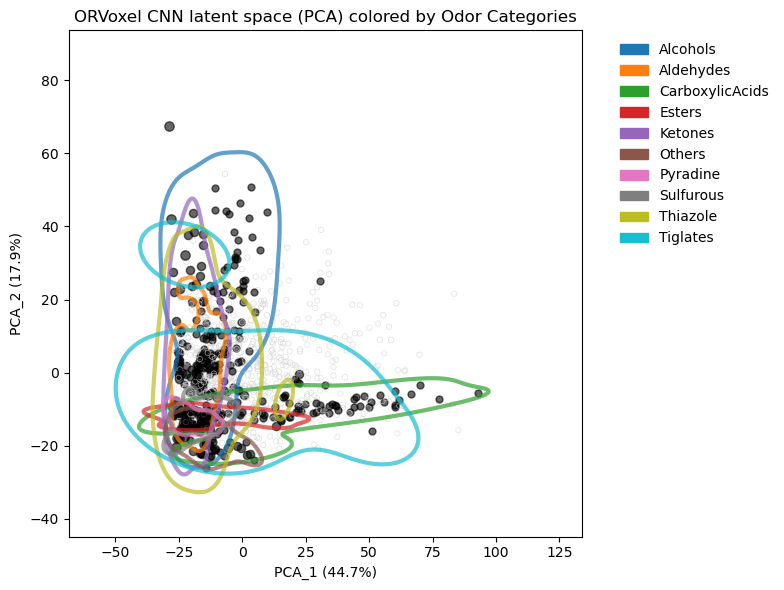

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from ast import literal_eval

pca_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/Features/spatialESM_OdorClass/pca_df.csv', index_col = 0)
pca_df['active_odors'] = pca_df['active_odors'].apply(literal_eval)

# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')

# --- Plot ---
plt.figure(figsize=(8,6))

# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in pca_df.iterrows():
    if row['active_odors']:
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    # color=color_map[row['active_odors'][0]],
                    color = 'black',
                    s=15 + (10*len(row['active_odors'])), alpha=0.6)
    else:
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    edgecolor = '#D3D3D3', facecolor='none',lw=0.5,
                    s=15, alpha=0.7)

# KDE contour per odor category
legend_patches = []
for odor in ODOR_CATEGORIES:
    subset = pca_df[[odor in active for active in pca_df['active_odors']]]
    if len(subset) < 2:
        continue  # skip odors with too few ORs
    sns.kdeplot(
        x=subset['PCA_1'], y=subset['PCA_2'],
        levels=2,
        thresh=0.1,
        color=color_map[odor],
        linewidths=3,
        alpha=0.7,
        label=odor,
        warn_singular=False
    )
    legend_patches.append(mpatches.Patch(color=color_map[odor], label=odor))



plt.legend(handles=legend_patches,
           edgecolor='None', markerscale=2,
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel(f'PCA_1 ({pca_variance[0]*100:.1f}%)')
plt.ylabel(f'PCA_2 ({pca_variance[1]*100:.1f}%)')
plt.title("ORVoxel CNN latent space (PCA) colored by Odor Categories")
plt.tight_layout()

plt.savefig('/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/Features/PCA/feature_pca.png', dpi=300)
plt.show()

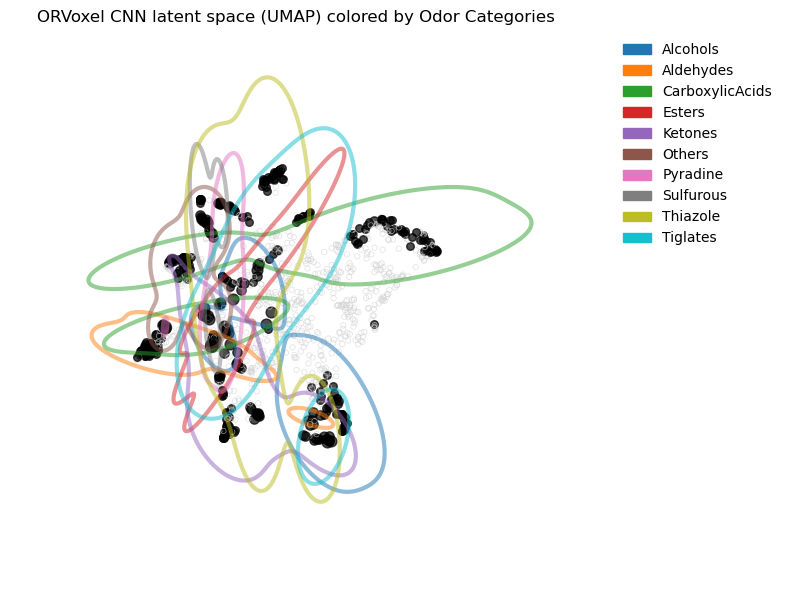

In [ ]:
import matplotlib.patches as mpatches
import umap 
import re 

umap_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/Features/spatialESM_OdorClass/umap_df.csv', index_col = 0)
umap_df['active_odors'] = umap_df['active_odors'].apply(literal_eval)

# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')

# --- Plot ---
plt.figure(figsize=(8,6))

# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in umap_df.iterrows():
    if row['active_odors']:
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    color = 'black',
                    s=15 + (15*len(row['active_odors'])), alpha=0.7)
    else:
        # plt.scatter(row['UMAP_1'], row['UMAP_2'], color='lightgray', s=15, alpha=0.4)
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    edgecolor = '#d3d3d3', facecolor='none',lw=0.5,
                    s=15, alpha=0.7)

legend_patches = []
# KDE contour per odor category
for odor in ODOR_CATEGORIES:
    subset = umap_df[[odor in active for active in umap_df['active_odors']]]
    if len(subset) < 2:
        continue  # skip odors with too few ORs
    sns.kdeplot(
        x=subset['UMAP_1'], y=subset['UMAP_2'],
        levels=2,
        thresh=0.1,
        color=color_map[odor],
        linewidths=3,
        alpha=0.5,
        label=odor,
        warn_singular=False, 
        legend=True
    )
    legend_patches.append(mpatches.Patch(color=color_map[odor], label=odor))


plt.xlabel(f'UMAP_1')
plt.ylabel(f'UMAP_2')
plt.title("ORVoxel CNN latent space (UMAP) colored by Odor Categories")
plt.legend(handles=legend_patches,
           edgecolor='None', markerscale=2,
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.savefig('/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/Features/Umap/feature_umap.png', dpi=300)
plt.show()

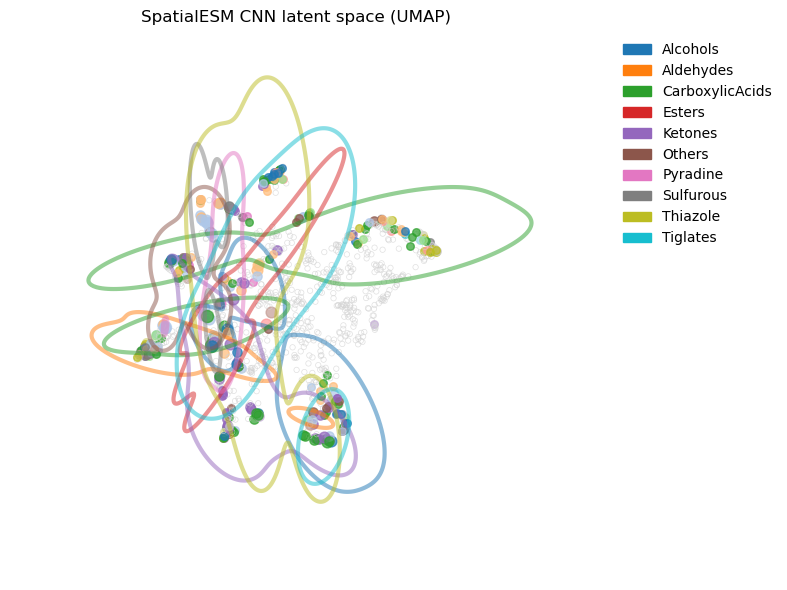

In [83]:
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import seaborn as sns
import re 
from ast import literal_eval

"""
Plot by class / family
"""

umap_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/Umap/umap_df.csv', index_col = 0)
umap_df['active_odors'] = umap_df['active_odors'].apply(literal_eval)
umap_df['Class'] = [1 if int(_fam) > 50 else 2 for _fam in umap_df.family]

scatter_color_by = 'family'
# --- Plot ---
plt.figure(figsize=(8,6))
color_scatter = cf.distinct_colors(umap_df[scatter_color_by].sort_values().unique(), category='tab20')
# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in umap_df.iterrows():
    if row['active_odors']:
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    color = color_scatter.get(row[scatter_color_by]),
                    s=15 + (15*len(row['active_odors'])), alpha=0.7
                    )
    else:
        # plt.scatter(row['UMAP_1'], row['UMAP_2'], color='lightgray', s=15, alpha=0.4)
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    edgecolor = '#d3d3d3', facecolor='none',lw=0.5,
                    s=15, alpha=0.7)
scatter_legend=[]
# scatter_legend = [mpatches.Patch(color=color_scatter[_legend], label=f'{scatter_color_by} {_legend}') for _legend in umap_df[scatter_color_by].unique()]


# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')
odor_legend = []
# KDE contour per odor category
for odor in ODOR_CATEGORIES:
    subset = umap_df[[odor in active for active in umap_df['active_odors']]]
    if len(subset) < 2:
        continue  # skip odors with too few ORs
    sns.kdeplot(
        x=subset['UMAP_1'], y=subset['UMAP_2'],
        levels=2,
        thresh=0.1,
        color=color_map[odor],
        linewidths=3,
        alpha=0.5,
        label=odor,
        warn_singular=False, 
        legend=True
    )
    odor_legend.append(mpatches.Patch(color=color_map[odor], label=odor))


plt.xlabel(f'UMAP_1')
plt.ylabel(f'UMAP_2')
plt.title("SpatialESM CNN latent space (UMAP)")
plt.legend(handles=odor_legend + scatter_legend,
           edgecolor='None', markerscale=2,
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/Umap/feature_umap_{scatter_color_by}.png', dpi=300)
plt.show()

In [ ]:
"""
Batch Export individual graphs for each odor 
"""

import matplotlib.patches as mpatches
import umap 
import re 

umap_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/Features/spatialESM_OdorClass/umap_df.csv', index_col = 0)
umap_df['active_odors'] = umap_df['active_odors'].apply(literal_eval)

# Assign a color per odor
color_family = cf.distinct_colors(np.sort(umap_df.family.unique()), category='tab20')
# --- Plot ---

color_odor = {'Alcohols': '#1f77b4','Aldehydes': '#ff7f0e','CarboxylicAcids': '#2ca02c',
              'Esters': '#d62728', 'Ketones': '#9467bd','Others': '#8c564b',
              'Pyradine': '#e377c2','Sulfurous': '#7f7f7f','Thiazole': '#bcbd22','Tiglates': '#17becf'}

# KDE contour per odor category
for odor in ODOR_CATEGORIES:
# for odor in ['Sulfurous']:
    subset = umap_df[[odor in active for active in umap_df['active_odors']]]
    if len(subset) < 2:
        continue  # skip odors with too few ORs
    
    plt.figure(figsize=(8,6))
    sns.kdeplot(
        x=subset['UMAP_1'], y=subset['UMAP_2'],
        levels=2,
        thresh=0.1,
        color=color_odor[odor],
        linewidths=3,
        alpha=0.5,
        label=odor,
        warn_singular=False, 
        legend=True
    )
    odor_patches = [mpatches.Patch(color=color_map[odor], label=odor)]

    for idx, row in umap_df.iterrows():
        if row['active_odors']:
            plt.scatter(row['UMAP_1'], row['UMAP_2'],
                        color = color_family.get(row['family']),
                        s=15 + (15*len(row['active_odors'])), alpha=0.7)
        else:
            # plt.scatter(row['UMAP_1'], row['UMAP_2'], color='lightgray', s=15, alpha=0.4)
            plt.scatter(row['UMAP_1'], row['UMAP_2'],
                        edgecolor = '#d3d3d3', facecolor='none',lw=0.5,
                        s=15, alpha=0.7)
    family_patches = [mpatches.Patch(color=col, label=fam) 
                    for fam, col in color_family.items()]

    plt.xlabel(f'UMAP_1')
    plt.ylabel(f'UMAP_2')
    plt.title(f"spatialESM CNN latent space (UMAP) - {odor}")
    plt.legend(handles=family_patches + odor_patches,
            edgecolor='None', markerscale=2,
            bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/Features/Umap/feature_umap_{odor}.png', dpi=300)
    plt.show()

#### Importance Extraction

In [10]:
"""
Initialize Variables
"""

import os 
import sys
import pandas as pd 
import numpy as np 
from ast import literal_eval

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 
import SequenceAlignment_functions as sa 

# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()


base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Odorclassify/param_sweep1/20250911_184516_lr0.0001_bs8_hd16_ks5_nl2_do0.2_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

odor_importances_zscore = np.load(os.path.join(base_dir, f"odor_importances_zscore.npy"), allow_pickle=True).item()

# Load in voxel information
voxels_info = pd.read_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/voxels_info.csv', index_col=0)
voxels_info['odor_response'] = voxels_info['odor_response'].apply(literal_eval)

ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

# """
# Make Voxel_info df 
# """

# odor_activation = all_labels.astype(bool)
# # For convenience, store which ORs are activated by which odor
# all_labels_odors = []
# for i in range(odor_activation.shape[0]):
#     active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(odor_activation[i]) if v]
#     all_labels_odors.append(active_odors)
    
# import re
# fam = []
# for or_name in voxel_names:
#     fam.append(int(re.match(r'Or(\d+)', or_name, re.IGNORECASE).group(1)))

# # Make voxel_info df 
# voxels_info = pd.DataFrame([_name.capitalize() for _name in voxel_names], columns = ['voxel_name'])
# voxels_info['OR'] = voxels_info.voxel_name.str.split('_').str[0]
# voxels_info['family'] = fam
# voxels_info['label'] = list(all_labels.astype(int))
# voxels_info['odor_response'] = list(all_labels_odors)

# voxels_info.to_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/voxels_info.csv')

In [6]:
"""
Reload the voxel in sparse form and no radius for visualization 
"""


Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

voxels_info = pd.read_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/voxels_info.csv', index_col = 0)
# voxel_names = np.load(os.path.join(base_dir, "voxel_names.npy"), allow_pickle=True)


# Extracting the voxels used in model 
Cbc_cav_coords = {_key: _values for _key, _values in Cbc_cav_coords.items() if _key.capitalize() in list(voxels_info.voxel_name)}
Cbc_res_coords = {_key: _values for _key, _values in Cbc_res_coords.items() if _key.capitalize() in list(voxels_info.voxel_name)}

center_reference = np.load('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_center_reference.npy')
voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                        residue_coords = Cbc_res_coords,
                                        resolution = 1, 
                                        cube_dim = 32, reference_center = center_reference, 
                                        encode_method='res', 
                                        sparse_mode=True, 
                                        vdw_radius = True)

voxel_names = list(Cbc_res_coords.keys())

# Trim down voxels to save memory 
del Cbc_cav_coords, Cbc_res_coords

Encoding voxels via res...
Generating voxels. . .


100%|██████████| 1060/1060 [01:02<00:00, 16.93it/s]


In [11]:
from Bio import SeqIO
import SequenceAlignment_functions as sa
"""
Read in sequence alignment file 
"""
fasta_path = '/mnt/data2/Justice/OR_learning/files/OR_seq/mouseOR_alignment.fasta'
Olfr_DL = np.load('/mnt/data2/Justice/OR_learning/files/Olfr_DL.npy', allow_pickle=True).item()

sequences = []
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_str = str(record.seq)
    sequences.append((record.id, seq_str))

alignment_df = pd.DataFrame(
    [list(seq) for _, seq in sequences],
    columns=range(1, len(sequences[0][1]) + 1),
    index=[Olfr_DL.get(seq_id, seq_id).capitalize() for seq_id, _ in sequences]
)
alignment = alignment_df.apply(lambda row: ''.join(row.values), axis=1).to_dict()


"""
BW position mapping 
"""
Or51E2_bw_positions = {"N41":'1.50', "D69": '2.50', "R121":'3.50', 
                       "V149":'4.50', "C178":'45.50', "D209":'5.50', 
                       "P253":'6.50', "P288":'7.50'}
Or51E2_bw_positions = {f"{_k[0]}{int(_k[1:])}": Or51E2_bw_positions[_k] for _k in Or51E2_bw_positions}

# Create alignment bw reference position, This position is True bw for the entire alignment 
alignment_bw = sa.update_bw_positions("Or51e2", alignment, Or51E2_bw_positions)


In [ ]:
import plotly.graph_objects as go 

importance_threshold = 5


IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
IDX_TO_AA_RES_SINGLE = {i+1: sa.AA_THREE_TO_ONE.get(res) for i, res in enumerate(vf.AA_RES_OHE)}

for _ODOR in ODOR_CATEGORIES:
    # Make consesnus voxel instead of plotting all the individual voxels overlaying each other 
    subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _ODOR in x)].reset_index(names='voxel_idx')
    plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]

    # Convert voxel indices to residue names + numbers
    for idx, row in subset_voxels_info.iterrows():
        res_to_map = [ IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]

        res_bw_dict = sa.map_residues_to_bw(residue_list = res_to_map,
                                            alignment = alignment, 
                                            target_seq_name = row.OR, 
                                            bw_positions = alignment_bw)
        
        # Update plot_voxel for the bw labels 
        updated_plot_voxels = {}
        for coord, tensor_val in plot_voxels[idx].items():
            res_num = int(tensor_val[0].item())
            res_idx = int(tensor_val[1].item())
            
            # Convert residue index -> AA letter
            aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
            res_key = f"{aa}{res_num}"
            
            # Lookup BW number if available
            bw_number = res_bw_dict.get(res_key, None)
            
            # Store as (res_num, res_idx, bw_number)
            updated_plot_voxels[coord] = (res_num, res_idx, bw_number)
            
        plot_voxels[idx] = updated_plot_voxels



    plot_voxels_cons = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.2, use_bw=True)
    positions = np.array(list(plot_voxels_cons))


    X, Y, Z = positions[:,0], positions[:,1], positions[:,2]

    res = np.array(list(plot_voxels_cons.values()))[:,0].astype(int)
    cons_ratio = np.array(list(plot_voxels_cons.values()))[:,1].astype(float)
    bw = np.array(list(plot_voxels_cons.values()))[:,2].astype(str)

    color = cf.distinct_colors(list(vf.AA_RES_OHE), category='tab20')
    IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=X, y=Y, z=Z,
        mode='markers',
        name=_ODOR,
        marker=dict(
            size=10,  # adjust marker size
            color=[color.get(IDX_TO_AA_RES.get(_res)) for _res in res],  # importance values
            opacity=0.8
        ), 
        # text=[f"Residue {n} {IDX_TO_AA_RES.get(r)}" for n, r in zip(res_num.astype(int), res)],  # hover text
        text=[f"{IDX_TO_AA_RES.get(_r)}, {_bw} {np.round(_ratio, 2)}%" for _r, _bw, _ratio in zip(res, bw, cons_ratio)],  # hover text
        hoverinfo="text"
    ))
        
        
    # Add importance volumes
    # plot_voxel = odor_importances_zscore[_ODOR]
    # X, Y, Z = np.indices(plot_voxel.shape)

    # fig.add_trace(go.Volume(
    #     x=X.flatten(),
    #     y=Y.flatten(),
    #     z=Z.flatten(),
    #     name='feature', 
    #     value=[i if np.abs(i) >= importance_threshold else 0 for i in plot_voxel.flatten()],
    #     isomin=-np.max(np.abs(plot_voxel)),
    #     isomax= np.max(np.abs(plot_voxel)),
    #     opacity=0.5,  # global scaling factor
    #     surface_count=10,  # number of contour surfaces
    #     colorscale="RdBu_r", # red/blue diverging
    #     showscale=False,
    #     showlegend=True, 
    #     hoverinfo='skip', 
    #     caps=dict(x_show=False, y_show=False, z_show=False)  # hide box caps
    # ))

    # Add importance as scatter
    plot_voxel = odor_importances_zscore[_ODOR]
    occupied_voxels = np.array(np.where((np.abs(plot_voxel) >= importance_threshold))).T
    x, y, z = occupied_voxels[:, 0], occupied_voxels[:, 1], occupied_voxels[:, 2]
    values = plot_voxel[x, y, z]

    # Plot scatter with color scale
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        name="Importance",
        marker=dict(
            size=3,  # adjust marker size
            color=values,  # importance values
            colorscale="RdBu_r",  # red-blue colormap
            cmin=-np.max(np.abs(values)),  # symmetric color range
            cmax=np.max(np.abs(values)),
            opacity=1,
            colorbar=dict(title="Importance", 
                          len=0.7,  # Length of the colorbar (fraction of plot height)
                          lenmode='fraction', # Can be 'fraction' or 'pixels'
                          thickness=20, # Thickness of the colorbar in pixels
                          thicknessmode='pixels'
                          )
        )
    ))

    # Determine global min/max from both scatter and volume
    # Collect all x, y, z across traces in fig.data
    all_x, all_y, all_z = [], [], []
    for trace in fig.data:
        if hasattr(trace, "x") and trace.x is not None:
            all_x.extend(trace.x)
        if hasattr(trace, "y") and trace.y is not None:
            all_y.extend(trace.y)
        if hasattr(trace, "z") and trace.z is not None:
            all_z.extend(trace.z)

    # Convert to arrays for min/max
    all_x, all_y, all_z = np.array(all_x), np.array(all_y), np.array(all_z)

    fig.update_layout(
        scene=dict(
            xaxis=dict(range=[all_x.min(), all_x.max()], autorange=False),
            yaxis=dict(range=[all_y.min(), all_y.max()], autorange=False),
            zaxis=dict(range=[all_z.min(), all_z.max()], autorange=False),
            aspectmode="cube"  # keeps scaling equal across axes
        )
    )

    fig = pf._plotly_blank_style(fig)

    # fig.write_html(f'/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/Importance/volume/{_ODOR}_Importance_ConsVox_volume.html')
    # fig.write_html(f'/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/Importance/scatter/{_ODOR}_Importance_ConsVox_scatter.html')

    fig.show()
    break
        

#### importance snakeplot

In [4]:
import os 
import sys
import pandas as pd 
import numpy as np 
from ast import literal_eval

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 
import SequenceAlignment_functions as sa 

# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()


base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Odorclassify/param_sweep1/20250911_184516_lr0.0001_bs8_hd16_ks5_nl2_do0.2_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

# voxel_names = np.load(os.path.join(base_dir, "voxel_names.npy"), allow_pickle=True)
# all_features = np.load(os.path.join(base_dir, f"embeddings.npy"))
# all_labels = np.load(os.path.join(base_dir, f"labels.npy"))
# all_importances = np.load(os.path.join(base_dir, f"all_importances.npy"), allow_pickle=True).item()
odor_importances_zscore = np.load(os.path.join(base_dir, f"odor_importances_zscore.npy"), allow_pickle=True).item()

# Load in voxel information
voxels_info = pd.read_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/voxels_info.csv', index_col=0)
voxels_info['odor_response'] = voxels_info['odor_response'].apply(literal_eval)
# voxels_info['label'] = voxels_info['label'].apply(literal_eval)


In [31]:
"""
Reload the voxel in sparse form and no radius for visualization 
"""

Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

# Extracting the voxels used in model 
Cbc_cav_coords = {_key: _values for _key, _values in Cbc_cav_coords.items() if _key.capitalize() in list(voxels_info.voxel_name)}
Cbc_res_coords = {_key: _values for _key, _values in Cbc_res_coords.items() if _key.capitalize() in list(voxels_info.voxel_name)}

center_reference = np.load('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_center_reference.npy')
voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                        residue_coords = Cbc_res_coords,
                                        resolution = 1, 
                                        cube_dim = 32, reference_center = center_reference, 
                                        encode_method='res', 
                                        sparse_mode=True, 
                                        vdw_radius = True)

# Trim down voxels to save memory 
# del Cbc_cav_coords, Cbc_res_coords

Encoding voxels via res...
Generating voxels. . .


100%|██████████| 1060/1060 [01:01<00:00, 17.24it/s]


In [9]:
from Bio import SeqIO
import SequenceAlignment_functions as sa
"""
Read in sequence alignment file 
"""
fasta_path = '/mnt/data2/Justice/OR_learning/files/OR_seq/mouseOR_alignment.fasta'
Olfr_DL = np.load('/mnt/data2/Justice/OR_learning/files/Olfr_DL.npy', allow_pickle=True).item()

sequences = []
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_str = str(record.seq)
    sequences.append((record.id, seq_str))

alignment_df = pd.DataFrame(
    [list(seq) for _, seq in sequences],
    columns=range(1, len(sequences[0][1]) + 1),
    index=[Olfr_DL.get(seq_id, seq_id).capitalize() for seq_id, _ in sequences]
)
alignment = alignment_df.apply(lambda row: ''.join(row.values), axis=1).to_dict()


"""
Generate BW position mapping 
"""
Or51E2_bw_positions = {"N41":'1.50', "D69": '2.50', "R121":'3.50', 
                       "V149":'4.50', "C178":'45.50', "D209":'5.50', 
                       "P253":'6.50', "P288":'7.50'}
Or51E2_bw_positions = {f"{_k[0]}{int(_k[1:])}": Or51E2_bw_positions[_k] for _k in Or51E2_bw_positions}

# Create alignment bw reference position, This position is True bw for the entire alignment 
alignment_bw = sa.update_bw_positions("Or51e2", alignment, Or51E2_bw_positions)


In [207]:
from collections import Counter

pd.set_option('display.max_columns', None)
percent_dashes = (alignment_df == '-').sum(axis=0) / alignment_df.shape[0] * 100
drop_threshold = 60

cols_to_drop = percent_dashes[percent_dashes >= drop_threshold].index.tolist()
consensus_df = alignment_df.drop(columns=cols_to_drop)
consensus_df.columns = list(range(len(consensus_df.columns))) # Re-name columns 

print("Filtered DataFrame shape:", consensus_df.shape)
consensus_letters = []
for col in consensus_df.columns:
    col_data = consensus_df[col]
    counts = Counter(col_data[col_data != '-'])
    if counts:
        consensus_letters.append(counts.most_common(1)[0][0])
    else:
        consensus_letters.append(' ')

# Rename to DL_OR instead 
# np.load('../files/Olfr_DL.npy', allow_pickle=False).item
consensus_df.head()

Filtered DataFrame shape: (1107, 317)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316
Or12d12,-,-,M,S,N,Q,T,S,V,T,E,F,L,L,L,G,V,T,D,I,Q,E,L,N,P,I,L,F,V,I,F,F,T,I,Y,F,I,N,I,T,G,N,G,A,I,L,M,I,V,I,L,D,P,L,H,S,-,P,M,Y,F,F,L,G,N,L,A,C,L,D,I,S,Y,S,T,V,T,V,P,K,L,L,Q,N,L,L,S,-,-,-,K,A,I,S,F,L,G,C,I,T,Q,L,H,F,F,H,F,L,G,S,T,E,T,M,L,L,P,V,M,A,F,D,R,F,V,A,I,C,R,P,L,H,Y,S,V,I,M,N,H,Q,L,C,I,H,M,T,V,T,I,W,T,L,G,-,F,F,H,A,L,L,H,S,V,M,T,S,R,L,S,F,C,G,P,N,-,V,H,H,F,F,C,D,I,K,P,L,L,D,L,A,C,G,N,T,E,L,N,L,W,L,L,N,T,V,T,G,T,I,A,L,T,S,F,F,L,I,F,L,S,Y,F,Y,I,I,T,N,L,L,L,K,T,R,S,C,S,M,H,K,A,L,S,T,C,A,S,H,F,M,V,V,V,L,F,Y,A,P,V,L,F,T,Y,I,R,P,A,S,G,-,-,S,S,L,D,Q,D,T,I,A,I,M,Y,S,V,V,T,P,A,L,N,P,L,I,Y,T,L,R,N,K,E,V,R,S,A,L,N,R,K,V,R,R,W,L,-,-,-,-,-
Or12d2,-,-,M,S,N,Q,T,S,V,T,E,F,L,L,L,G,V,T,D,V,Q,E,L,N,P,I,L,F,V,I,F,F,T,I,Y,F,V,N,I,T,G,N,G,A,I,L,M,I,V,I,L,D,P,L,H,S,-,P,M,Y,F,F,L,G,N,L,A,C,L,D,I,C,F,S,T,V,T,L,P,K,M,L,Q,N,L,L,S,-,-,-,K,A,I,S,F,L,G,C,I,T,Q,L,H,F,F,H,F,L,G,S,T,E,A,M,L,L,P,V,M,A,F,D,R,F,V,A,I,C,R,P,L,H,Y,S,V,I,M,N,H,Q,L,C,I,H,M,T,V,T,I,W,T,L,G,-,F,F,H,A,L,L,H,S,V,M,T,S,R,L,S,F,C,G,P,N,-,V,H,H,F,F,C,D,I,K,P,L,L,D,L,A,C,G,N,T,E,L,N,L,W,L,L,N,T,V,T,G,T,I,A,L,T,P,F,F,L,T,F,L,S,Y,F,Y,I,I,I,Y,L,L,L,K,T,R,S,C,S,M,H,K,A,L,S,T,C,A,S,H,F,M,V,V,F,L,F,Y,A,P,V,L,F,I,Y,I,S,P,T,S,G,-,-,S,S,L,D,Q,D,R,I,A,I,M,Y,S,V,V,T,P,A,L,N,P,L,I,Y,T,L,R,N,K,E,V,R,S,A,L,N,R,K,L,R,R,W,L,-,-,-,-,-
Or12d13,-,-,M,L,N,Q,T,S,V,T,E,F,I,L,L,G,V,R,D,I,Q,E,P,Q,P,F,L,F,A,I,F,F,T,I,Y,F,V,N,I,T,G,N,G,A,I,L,M,I,V,I,L,D,P,L,H,S,-,P,M,Y,F,F,L,G,N,L,A,C,L,D,I,S,Y,S,T,V,T,V,P,K,M,L,E,N,L,L,S,-,-,-,K,A,I,S,L,L,G,C,I,T,Q,L,H,F,F,H,F,L,G,T,T,E,S,L,L,L,A,V,M,A,F,D,R,F,V,A,I,C,R,P,L,H,Y,S,V,I,M,N,W,Q,V,C,I,L,M,A,V,T,I,W,T,I,A,-,F,L,H,A,L,L,H,S,V,M,T,S,R,L,S,F,C,G,L,N,-,I,H,H,F,F,C,D,V,K,P,L,L,E,L,A,C,G,N,T,E,L,N,L,W,L,L,N,T,V,T,G,T,I,A,S,V,P,F,F,L,T,F,L,S,Y,F,Y,I,I,T,Y,L,F,L,K,T,R,S,C,S,M,H,K,A,L,S,T,C,A,S,H,F,M,V,V,V,L,F,Y,A,P,V,L,F,T,Y,I,R,P,T,S,G,-,-,S,S,L,D,Q,D,R,I,A,I,M,Y,S,V,V,T,P,A,L,N,P,L,I,Y,T,L,R,N,K,E,V,R,S,A,L,N,R,K,V,R,R,C,L,L,L,E,E,I
Or12d17,-,-,M,E,N,S,T,S,V,D,E,F,L,L,L,G,L,T,S,V,Q,K,L,Q,P,I,I,F,V,M,F,L,T,I,Y,L,L,N,L,V,G,N,G,V,I,L,M,I,V,T,L,E,R,L,H,S,-,P,M,Y,F,F,L,G,N,L,S,C,L,D,I,C,Y,S,S,V,T,L,P,K,V,L,I,N,L,L,S,-,-,-,R,A,I,S,F,L,G,C,I,T,Q,L,Y,F,F,H,F,L,G,S,T,E,A,I,L,L,A,V,M,A,F,D,R,F,V,A,I,C,S,P,L,R,Y,T,A,I,M,N,P,Q,L,C,I,L,L,A,A,T,A,W,F,T,S,-,F,F,Y,A,L,L,H,S,V,M,T,A,H,L,N,F,C,H,S,H,-,L,S,H,F,F,C,D,V,K,P,L,L,E,V,A,C,G,N,T,V,L,N,Q,W,L,L,S,V,V,T,G,S,I,S,M,G,A,F,L,L,I,L,L,S,Y,F,Y,I,I,A,F,L,L,F,K,N,R,S,C,R,M,K,K,A,L,S,T,C,T,S,H,F,M,V,V,C,L,F,Y,G,P,V,G,F,T,Y,I,R,P,A,T,A,S,A,S,S,M,S,E,D,R,V,A,I,I,Y,S,A,V,T,P,V,L,N,P,L,I,Y,T,L,R,N,K,E,V,M,L,A,L,K,K,N,F,G,K,K,L,F,K,G,N,-
Or4p18,-,-,M,E,S,T,N,N,I,T,E,F,I,L,L,G,L,S,Q,N,K,K,I,K,A,L,C,F,L,M,F,L,F,C,Y,I,A,I,L,G,G,N,M,I,I,L,I,S,I,T,C,S,Q,I,E,-,Q,P,M,Y,F,F,L,N,Y,L,A,L,S,D,L,C,Y,T,S,T,V,T,P,K,F,L,T,D,L,L,V,-,-,-,N,K,I,S,Y,T,S,C,M,A,Q,L,F,T,M,H,F,F,G,G,I,E,I,L,I,L,T,V,M,A,Y,D,R,Y,V,A,I,C,K,P,L,H,Y,S

In [217]:
import pandas as pd
from collections import Counter

def filter_get_conservation(df, filter_names=None):
    """
    Compute consensus sequence and conservation from a filtered alignment DataFrame.

    Args:
        df (pd.DataFrame): Filtered alignment (rows = sequences, cols = positions).
        filter_names (list, optional): List of sequence IDs (row labels) to include. 
                                       If None, use all rows.

    Returns:
        consensus_letters (list of str): Consensus amino acid at each position.
        conservation_percent (list of float): Percent conservation at each position.
        positions (list): Column labels corresponding to positions.
    """
    # Subset rows if filter is given
    if filter_names is not None:
        df = df.loc[df.index.intersection(filter_names)]
    
    if df.empty:
        raise ValueError("No sequences found after filtering. Check filter_names or df index.")
    
    consensus_letters = []
    conservation_percent = []

    for col in df.columns:
        col_data = df[col]
        # Exclude gaps
        aa_series = col_data[col_data != '-']
        counts = Counter(aa_series)
        if counts:
            most_common_aa, count = counts.most_common(1)[0]
            consensus_letters.append(most_common_aa)
            conservation_percent.append(count / len(aa_series) * 100)
        else:
            consensus_letters.append(' ')
            conservation_percent.append(0.0)
    
    return df, consensus_letters, conservation_percent

In [ ]:
"""
Generate Snakeplot importance for strongest importance. 
Note that for a given BW there may be both importance assigned to different 3D spatial location ! 
"""

ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
IDX_TO_AA_RES_SINGLE = {i+1: sa.AA_THREE_TO_ONE.get(res) for i, res in enumerate(vf.AA_RES_OHE)}

for _ODOR in ODOR_CATEGORIES:
    # Make consesnus voxel instead of plotting all the individual voxels overlaying each other 
    subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _ODOR in x)].reset_index(names='voxel_idx')
    plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]

    # Convert voxel indices to residue names + numbers
    for idx, row in subset_voxels_info.iterrows():
        res_to_map = [ IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]

        res_bw_dict = sa.map_residues_to_bw(residue_list = res_to_map,
                                            alignment = alignment, 
                                            target_seq_name = row.OR, 
                                            bw_positions = alignment_bw)
        # Update plot_voxel for the bw labels 
        updated_plot_voxels = {}
        for coord, tensor_val in plot_voxels[idx].items():
            res_num = int(tensor_val[0].item())
            res_idx = int(tensor_val[1].item())
            
            # Convert residue index -> AA letter
            aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
            res_key = f"{aa}{res_num}"
            
            # Lookup BW number if available
            bw_number = res_bw_dict.get(res_key, None)
            
            # Store as (res_num, res_idx, bw_number)
            updated_plot_voxels[coord] = (res_num, res_idx, bw_number) 
        plot_voxels[idx] = updated_plot_voxels

    cons_voxel = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.2, use_bw=True)
    
        
    # Consensus voxel: (x,y,z) -> (res_num, consensus_ratio, bw_number)
    threshold = 2
    importance_vol = odor_importances_zscore[_ODOR] # [(odor_importances[_ODOR] >= threshold) | (odor_importances[_ODOR]  <= -threshold)]

    # Store per-BW importances
    bw_importances = defaultdict(list)

    for (x, y, z), (_, _, bw_num) in cons_voxel.items():
        if bw_num is None:  # skip if no BW mapping
            continue
        imp_val = importance_vol[x, y, z]
        if np.abs(imp_val) >= threshold:
            bw_importances[bw_num].append(imp_val)

    # Collapse per-BW: max abs or separate pos/neg
    bw_importances_strongest = {}
    for bw, vals in bw_importances.items():
        vals = np.array(vals)
        bw_importances_strongest[bw] = vals[np.argmax(np.abs(vals))]
        
    # Predetermined bw location for the default snake plot 
    bw_ref = {'1.50':42, '2.50':70, '3.50':123, '4.50':150, '45.50':181, '5.50':212, '6.50':256, '7.50':290} 

    # Get consensus_seq of responding ORs 
    alignment_df, consensus_seq, consensus_perc = filter_get_conservation(consensus_df.loc[list(subset_voxels_info.OR)])

    snakeplot_df = sp.make_snakedf(snake_labels = consensus_seq)
    snakeplot_df = sp.snake_df_label_bw(snakeplot_df, bw_ref)

    for _bw in bw_importances_strongest: 
        snakeplot_df.loc[snakeplot_df.bw == _bw, 'Importance'] = bw_importances_strongest[_bw]
        
    ax = sp.plt_snakeplot(snakeplot_df, color_by="Importance", 
                        label_position=[42, 70, 123, 150, 181, 212, 256, 290],
                        label_color='black',
                        cmap='RdBu_r', cmap_midpoint=0, 
                        show_colorbar=True, 
                        title=f'{_ODOR} Strongest BW Importance', title_text_size=15)
    # break
    ax.figure.savefig(f"/mnt/data2/Justice/OR_learning/output/spatialESM_OdorClass/Importance/snakeplot/{_ODOR}_Importance.png", dpi=300)
    

In [ ]:
temp = df.pivot_table(index = 'DL_OR', columns = 'odor', 
               values='activation_zscore')

odor,(+)-2-Octanol,(+)-Carvone,(+)-Limonene,(+)-Menthol,(-)-2-Octanol,(-)-Carvone,(-)-Menthol,(-)-dihydrocarveol,"2,5-Dimethylpyrazine",2-Butene-1-thiol,...,Pyridine,SBT,TBM,TMT,Trans-cinnamaldehyde,nTMT,p-Cresol,α-Pinene,β-Damascone,β-Ionone
DL_OR,,,,,,,,,,,,,,,,,,,,,
Or10A2,0.483315,-0.054610,-0.030137,-0.087754,0.231221,-0.077265,-0.039410,-0.252156,-0.076913,-0.083885,...,-0.100982,0.645028,-0.084160,-0.109171,-0.026371,-0.117064,-0.053647,-0.007733,-0.051682,-0.092895
Or10A3,7.950071,-0.039247,-0.030137,-0.152150,0.163401,-0.077265,-0.075263,-0.279814,-0.076913,-0.076762,...,-0.100982,-0.134870,-0.079478,-0.208000,-0.090145,-0.118256,-0.065440,-0.040348,-0.051682,-0.034677
Or10A3B,3.410807,-0.074324,-0.030137,-0.136079,0.016345,-0.077265,-0.077409,0.283044,-0.076913,-0.075492,...,-0.100982,-0.127003,-0.079617,-0.281885,-0.028285,-0.118256,-0.081553,-0.022660,-0.051682,-0.083448
Or10A3M,-0.125691,-0.074324,-0.030137,-0.118411,-0.123209,-0.077265,-0.212962,-0.396638,-0.076913,-0.089512,...,-0.137343,-0.134454,-0.083685,-0.091242,-0.049540,-0.118256,-0.089855,-0.040348,-0.051682,-0.117442
Or10A3N,-0.121834,-0.074324,-0.030137,-0.087754,0.276390,-0.077265,-0.075852,-0.285591,-0.076913,-0.075492,...,-0.179484,-0.121874,-0.106913,-0.088934,-0.070116,-0.118256,-0.081481,-0.040348,-0.051682,-0.089627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Or9S14,-0.141289,-0.059271,-0.030137,-0.117679,-0.123209,-0.077265,-0.075852,-0.270664,-0.076913,-0.077948,...,-0.112821,-0.105449,-0.083676,-0.086895,-0.039702,-0.118256,0.476417,-0.040348,-0.051682,-0.087342
Or9S15,0.323814,-0.074324,-0.030137,-0.086730,-0.055949,-0.077265,-0.052762,-0.277728,-0.076913,-0.081709,...,-0.102852,-0.134057,-0.082820,-0.104721,-0.046487,-0.118256,-0.080281,-0.040348,-0.051682,1.286248
Or9S18,-0.141726,-0.074324,-0.030137,-0.078819,-0.132814,-0.077265,-0.063085,0.170520,-0.076913,-0.073312,...,-0.102381,-0.114187,-0.083811,-0.091106,-0.027188,-0.118256,-0.068099,-0.040348,-0.051682,-0.089627


In [24]:
ps6_df[ps6_df.odor == 'Acetophenone'].odor_category.unique()[0]

'Ketones'

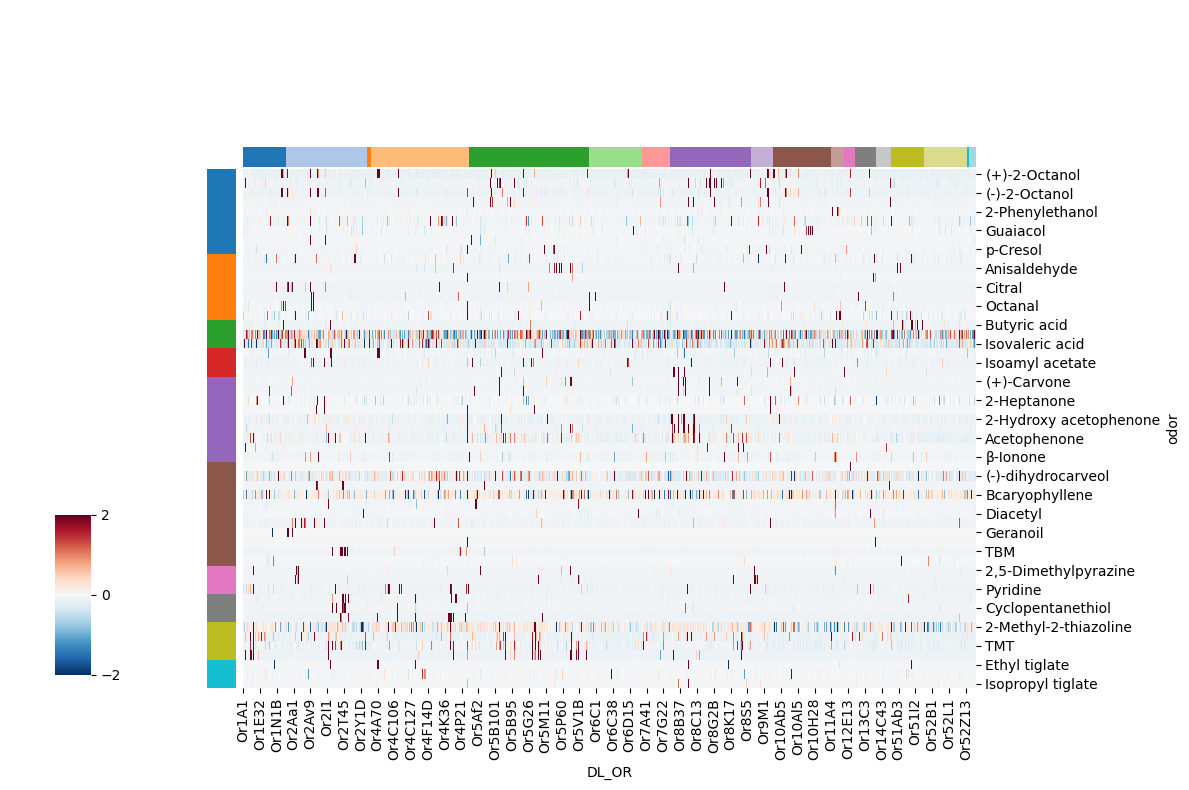

In [60]:
"""
QUICK PS6IP PLOT
"""

import seaborn as sns 

df = ps6_df[['cid', 'odor', 'odor_category', 'DL_OR', 'activation_zscore', 'Family']].sort_values(['odor_category', 'Family', 'DL_OR'])
temp = df.pivot_table(index = 'odor', columns = 'DL_OR', 
               values='activation_zscore', 
               sort=False)

odor_colors = cf.distinct_colors(ps6_df.odor_category.unique(), category='tab10')
odor_colorbar = [odor_colors.get(ps6_df[ps6_df.odor == _odor].odor_category.unique()[0]) for _odor in temp.index ]

fam_colors = cf.distinct_colors(ps6_df.Family.unique(), category='tab20')
fam_colorbar = [fam_colors.get(ps6_df[ps6_df.DL_OR == _OR].Family.unique()[0]) for _OR in temp.columns ]

g = sns.clustermap(temp, 
               cmap = 'RdBu_r',
               vmax = 2, vmin = -2, 
               center = 0, 
               cbar_pos = (0.05, 0.15, 0.03, 0.2), 
               row_colors = odor_colorbar, 
               col_colors = fam_colorbar,
               row_cluster = False, 
               col_cluster = False,
               cbar_kws={'ticks': [2,0,-2]},
               figsize=(12, 8)  # Adjust figure size to accommodate legends
               )


#### Odor WebLogo

In [256]:
bw_importances_strongest

{'3.32': 8.304554,
 '2.53': 5.725334,
 '3.33': 4.6923666,
 '3.37': -8.547676,
 '3.36': 4.18389,
 '3.40': -9.754683,
 '4.67': -10.775195,
 '4.71': -4.689755,
 '45.51': -4.513727,
 '5.42': 7.72658,
 '5.43': 7.4787235,
 '5.46': -12.432213,
 '5.47': -11.647503,
 '6.51': 3.6010756,
 '6.47': 12.259486,
 '6.55': -21.433035,
 '7.39': -7.9337797,
 '3.41': 4.3585186}

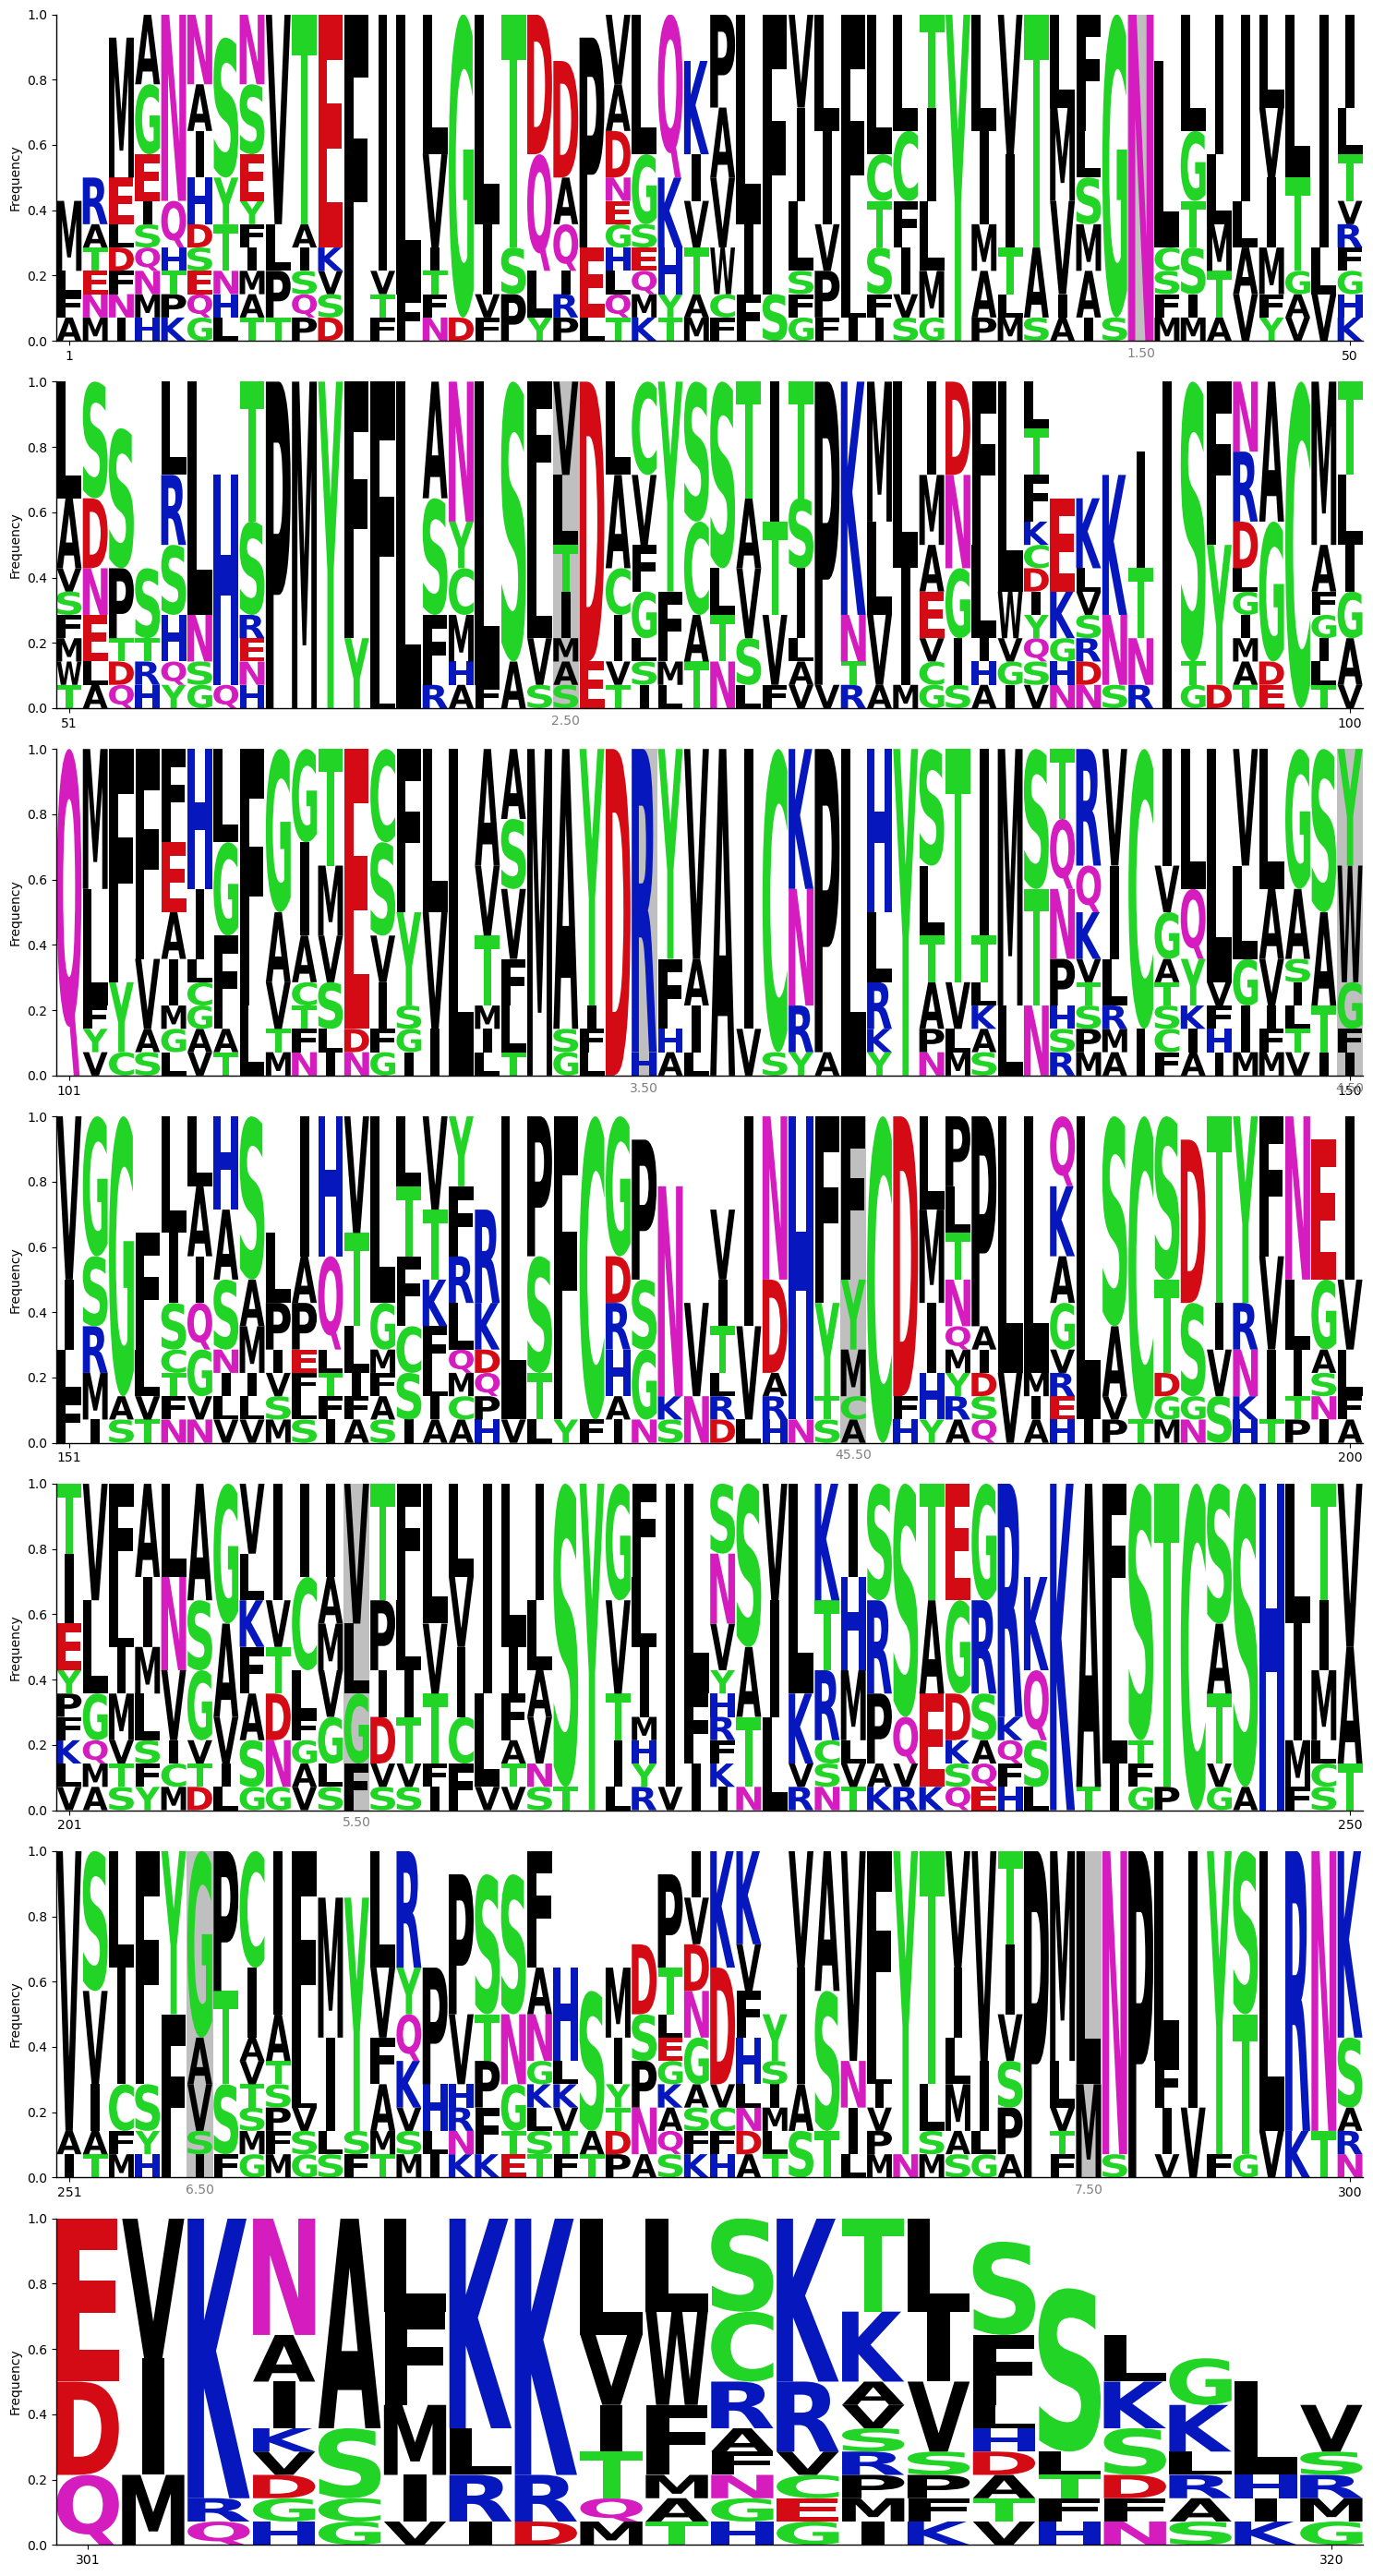

In [ ]:
import SequenceAlignment_functions as sa
import matplotlib.pyplot as plt
import logomaker 


# Define gap threshold (e.g., 90% gaps)
filtered_alignment, frequency_matrix = sa.trim_alignment({_key: _seq for _key, _seq in alignment.items() if _key in list(subset_voxels_info.OR)}, 
                                                         gap_threshold=0.6)


fig = pf.plot_weblogo(frequency_matrix, 
                      highlight_index=highlighted_mapping, 
                      bw_index=bw_ref, 
                      figsize=[15,4],
                      row_length=50)
# fig.savefig('../../output/Canonical_bc/SeqAlignment/SeqAlignment_Cbc.png')

In [233]:
pf.plot_weblogo(alignment_df)

IndexError: index 20 is out of bounds for axis 0 with size 14

#### Odor ROC curves
Not new. Adapted from bc_spatial_encoding_models_AF3.ipynb
simply plotting roc curves for individual Odors  

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, auc

# Load your single model outputs
run_name = "your_best_model"  # <-- change this
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Odorclassify/param_sweep1/20250911_184516_lr0.0001_bs8_hd16_ks5_nl2_do0.2_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

val_labels = np.load(os.path.join(base_dir, 'val_labels.npy'))
val_probs  = np.load(os.path.join(base_dir, 'val_probs.npy'))

# Load odor categories (must match label/prob indexing order)
ps6_df = pd.read_csv(
    '/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv',
    index_col=0
)
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

# Plot ROC curve for each odor separately
for i, odor in enumerate(ODOR_CATEGORIES):
    if np.sum(val_labels[:, i]) == 0:
        continue  # skip if class absent
    
    fpr, tpr, _ = roc_curve(val_labels[:, i], val_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, color="C0", lw=2, label=f"AUC={roc_auc:.2f}")
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f"ROC Curve — {odor}\nModel: {run_name}")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    
    plt.tight_layout()
    plt.show()

## SpatialAA Odor classification

In [ ]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA

# Replace with saved best model dir
# base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/top_params/20250905_104034_lr1e-05_bs4_hd16_ks5_nl1_do0.2_ptAVG_an0.5_am0.05_anum3_vt0.3_mlTrue'
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/top_params3_cd32/20250909_172949_lr1e-05_bs4_hd16_ks5_nl1_do0.2_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

params_path = os.path.join(base_dir, "params.json")
model_path = os.path.join(base_dir, "best_model.pt")

# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()


# Predefine the family classes once
ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

with open(params_path, "r") as f:
    params = json.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset definition 
class ORVoxelDataset(Dataset):
    def __init__(self, voxel_tensor, or_index_map, ps6_df, score_threshold=2.0):
        """
        voxel_tensor: [N_or, D, H, W, C]
        or_index_map: dict mapping OR name -> index in voxel_tensor
        ps6_df: dataframe containing DL_OR, odor_category, activation_zscore
        score_threshold: only include categories with zscore >= threshold
        """
        self.voxel_tensor = voxel_tensor
        self.or_names = list(or_index_map.keys())
        self.or_indices = list(or_index_map.values())

        self.targets = []

        for or_name in self.or_names:
            clean_or_name = or_name.split('_')[0].lower()
            df_sub = ps6_df[(ps6_df.DL_OR.str.lower() == clean_or_name) &
                            (ps6_df.activation_zscore >= score_threshold)]
            
            # print(clean_or_name, ps6_df.DL_OR.str.lower().unique())

            # Build binary target vector: 1 if activation_zscore >= threshold else 0
            target_vec = np.zeros(NUM_ODOR_CLASSES, dtype=np.float32)
            for _, row in df_sub.iterrows():
                idx = ODOR_TO_IDX[row.odor_category]
                target_vec[idx] = 1.0 

            self.targets.append(target_vec)

        self.targets = torch.tensor(np.array(self.targets), dtype=torch.float32)

    def __len__(self):
        return len(self.or_names)

    def __getitem__(self, idx):
        voxel = self.voxel_tensor[self.or_indices[idx]]
        target = self.targets[idx]
        return voxel, target
    
    
# ---------------- Model ----------------
class OROdorCNN(nn.Module):
    def __init__(self, voxel_shape=(41, 42, 65), num_classes=None,
                 kernel_size=3, hidden_dim=256,
                 num_conv_layers=2, conv_channels=(16, 32),
                 dropout=0.0, pool_type='AVG'):
        super().__init__()
        C, D, H, W = voxel_shape
        assert num_classes is not None, "num_classes must be set to number of odor categories"

        layers = []
        in_channels = C
        pool = nn.AvgPool3d if pool_type == 'AVG' else nn.MaxPool3d

        for i in range(num_conv_layers):
            out_channels = conv_channels[i]
            layers.append(
                nn.Conv3d(in_channels, out_channels,
                          kernel_size=kernel_size,
                          padding=kernel_size // 2)
            )
            layers.append(nn.ReLU())
            layers.append(pool(2))
            in_channels = out_channels

        self.cnn = nn.Sequential(*layers)

        # Compute flattened CNN output size
        dummy = torch.zeros(1, C, D, H, W)
        with torch.no_grad():
            out = self.cnn(dummy)
        self.cnn_out_dim = out.reshape(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(self.cnn_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)  # multi-label logits
        )

    def forward(self, voxel):
        # voxel: [B, D, H, W, C] → reorder for Conv3d
        voxel = voxel.permute(0, 4, 1, 2, 3)  # [B, C, D, H, W]
        cnn_out = self.cnn(voxel)
        cnn_out = cnn_out.reshape(cnn_out.size(0), -1)
        return self.fc(cnn_out)  # logits [B, num_classes]

    


In [ ]:
"""
Replicating the exact dataset model is trained on. 

It's important as the grid shape needs to match up as well. Or voxel grid may be misaligned. 
"""

import random

random.seed(0)

activated_ps6_df = ps6_df[ps6_df.activation_zscore >= 2]
zero_ps6_df = ps6_df[((ps6_df.activation_zscore <= 0.2) | 
                     (ps6_df.activation_zscore >= -0.2)) & 
                     (~ps6_df.DL_OR.isin(list(activated_ps6_df.DL_OR.unique())))]

Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')


# # For troubleshooting, using only positive activation_zscore 
# # Take x number of none activating ORs proportion to activated ORs. 
# sample_ORs = random.sample(list(zero_ps6_df.DL_OR.unique()), 
#                            len(list(activated_ps6_df.DL_OR.unique())) // 6) + list(activated_ps6_df.DL_OR.unique())
# # sample_ORs = list(activated_ps6_df.DL_OR.unique()) # No non-activated ORs
# sample_ORs = [_ORs.lower() for _ORs in sample_ORs]

# Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[0].lower() in sample_ORs}
# Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[0].lower() in sample_ORs}

# Taking only x prediction of each AF3
# Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[1] in (['0','1','2'])}
# Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[1] in (['0','1','2'])}
Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[1] in (['0'])}
Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[1] in (['0'])}

center_reference = np.load('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_center_reference.npy')
voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                        residue_coords = Cbc_res_coords,
                                        resolution = 1, 
                                        cube_dim = 32, reference_center = center_reference, 
                                        encode_method='ohe', 
                                        vdw_radius = True)
print(f'Grid shape: {grid_shape}')
voxel_names = list(Cbc_cav_coords.keys())


In [ ]:
# Load Model Weights 
voxel_tensor = torch.stack(voxels) 
voxel_shape = voxel_tensor.shape
C, D, H, W = voxel_shape[-1], voxel_shape[1], voxel_shape[2], voxel_shape[3]

model = OROdorCNN(
    voxel_shape=(C, D, H, W), # adjust if needed
    num_classes=NUM_ODOR_CLASSES,
    kernel_size=params["kernel_size"],
    hidden_dim=params["hidden_dim"],
    num_conv_layers=params["num_conv_layers"],
    conv_channels=tuple([16 * 2**i for i in range(params['num_conv_layers'])]),
    dropout=params["dropout"],
    pool_type=params["pooling"]
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

In [6]:
"""
Feature embedding and Importance extraction
"""

ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

def model_wrapper(voxel_input):
    """
    Forward pass through CNN + FC for Captum.
    voxel_input: [B,D,H,W,C]
    returns: logits [B,num_classes]
    """
    x = voxel_input.permute(0, 4, 1, 2, 3)           # [B,D,H,W,C] -> [B,C,D,H,W]
    x = model.cnn(x)
    x = x.reshape(x.size(0), -1)
    x = model.fc(x)                                  # use entire Sequential
    return x

def extract_features(model, x):
    x = x.permute(0, 4, 1, 2, 3)  # [B,D,H,W,C] -> [B,C,D,H,W]
    cnn_out = model.cnn(x)
    cnn_out = cnn_out.reshape(cnn_out.size(0), -1)
    # Use first Linear layer output as features
    features = model.fc[1](model.fc[0](cnn_out))  # fc[0]: Linear, fc[1]: ReLU
    return features


from captum.attr import IntegratedGradients

ig = IntegratedGradients(model_wrapper)

def compute_attributions_multilabel(
    voxel_batch, 
    target_vec=None, 
    mode="pred_or_true",   # "pred", "true", or "pred_or_true"
    top_k=3, 
    n_steps=10
):
    """
    Returns: a list of length B.
             Each item is a dict: {class_idx: importance_map [D,H,W]}
    """
    voxel_batch = voxel_batch.to(device)
    voxel_batch.requires_grad_()

    # Forward for probabilities (multi-label)
    with torch.no_grad():
        logits = model_wrapper(voxel_batch)     # [B, C]
        probs = torch.sigmoid(logits)           # [B, C]

    B, C = probs.shape
    per_b_results = []

    for b in range(B):
        # Decide which classes to explain for this sample
        if mode == "pred":
            classes = probs[b].topk(top_k).indices.tolist()
        elif mode == "true":
            assert target_vec is not None, "target_vec required for mode='true'"
            classes = torch.where(target_vec[b] > 0)[0].tolist()
            if len(classes) == 0:
                # nothing positive; skip or fall back to top-1
                classes = probs[b].topk(1).indices.tolist()
        else:  # "pred_or_true"
            assert target_vec is not None, "target_vec required for mode='pred_or_true'"
            classes = torch.where(target_vec[b] > 0)[0].tolist()
            if len(classes) == 0:  # fall back to predictions if no positives
                classes = probs[b].topk(top_k).indices.tolist()

        imps_b = {}
        for cls in classes:
            attrs = ig.attribute(
                voxel_batch[b:b+1],
                target=int(cls),
                baselines=torch.zeros_like(voxel_batch[b:b+1]),  # be explicit
                n_steps=n_steps,
                internal_batch_size=1
            )
            # Sum across channel dim (last dim of input is C after Captum returns)
            imp = attrs.detach().cpu().sum(dim=-1).squeeze(0)   # [D,H,W]
            imps_b[int(cls)] = imp
        per_b_results.append(imps_b)

    return per_b_results


n_voxels = len(voxels)

# Prepare input data 
dataset = ORVoxelDataset(voxels, {k: i for i, k in enumerate(voxel_names)}, ps6_df)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Extract Embedding
all_features, all_labels = [], []

# Initialize
all_importances = {}   # per OR, per odor
odor_importances = {odor: None for odor in ODOR_CATEGORIES}  # aggregated
odor_counts = {odor: 0 for odor in ODOR_CATEGORIES}          # for averaging

for or_idx, (voxel_batch, label_batch) in enumerate(dataloader):
    voxel_batch = voxel_batch.to(device)
    label_batch = label_batch.to(device)

    # 1) Extract per-OR embeddings
    feats = extract_features(model, voxel_batch)
    all_features.append(feats.cpu())
    all_labels.append(label_batch.cpu())

    # 2) Compute importances for this OR
    per_b = compute_attributions_multilabel(voxel_batch, label_batch, mode="pred_or_true", top_k=3, n_steps=10)
    imps_for_or = per_b[0]  # dict {cls_idx: [D,H,W]}

    # 3) Store per-OR importances
    or_name = dataset.or_names[or_idx]
    all_importances.setdefault(or_name, {})
    for cls_idx, imp in imps_for_or.items():
        odor_label = IDX_TO_ODOR[int(cls_idx)]
        all_importances[or_name][odor_label] = imp.numpy().astype("float32")

        # 4) Update aggregated odor_importances
        if odor_importances[odor_label] is None:
            odor_importances[odor_label] = imp.numpy().astype("float32")
        else:
            odor_importances[odor_label] += imp.numpy().astype("float32")
        odor_counts[odor_label] += 1

    del voxel_batch
    torch.cuda.empty_cache()

# Normalize aggregated odor importances by number of ORs contributing
for odor_label in odor_importances:
    if odor_importances[odor_label] is not None:
        odor_importances[odor_label] /= odor_counts[odor_label]

# Stack features and labels
all_features = torch.cat(all_features).detach().numpy()
all_labels = torch.cat(all_labels).detach().numpy()

# Save everything
# np.save(os.path.join(base_dir, "embeddings.npy"), all_features)
# np.save(os.path.join(base_dir, "labels.npy"), all_labels)
# np.save(os.path.join(base_dir, "voxel_names.npy"), voxel_names, allow_pickle=True)

# np.save(os.path.join(base_dir, "all_importances.npy"), all_importances, allow_pickle=True)
# np.save(os.path.join(base_dir, "odor_importances.npy"), odor_importances, allow_pickle=True)

np.save(os.path.join(base_dir, "embeddings2.npy"), all_features)
np.save(os.path.join(base_dir, "labels2.npy"), all_labels)
np.save(os.path.join(base_dir, "voxel_names2.npy"), voxel_names, allow_pickle=True)

np.save(os.path.join(base_dir, "all_importances2.npy"), all_importances, allow_pickle=True)
np.save(os.path.join(base_dir, "odor_importances2.npy"), odor_importances, allow_pickle=True)

print("Saved voxel names:", len(voxel_names))
print("Saved embeddings:", all_features.shape)
print("Saved labels:", all_labels.shape)
print("Saved per-OR importances:", len(all_importances))
print("Saved aggregated odor importances:", len(odor_importances))


Saved voxel names: 1115
Saved embeddings: (1115, 16)
Saved labels: (1115, 10)
Saved per-OR importances: 1115
Saved aggregated odor importances: 10


In [ ]:
import os 
import sys
import pandas as pd 
import numpy as np 

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 


# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()


# base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/top_params/20250905_104034_lr1e-05_bs4_hd16_ks5_nl1_do0.2_ptAVG_an0.5_am0.05_anum3_vt0.3_mlTrue'
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/top_params3_cd32/20250909_172949_lr1e-05_bs4_hd16_ks5_nl1_do0.2_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

# voxel_names = np.load(os.path.join(base_dir, "voxel_names.npy"), allow_pickle=True)
# all_features = np.load(os.path.join(base_dir, f"embeddings.npy"))
# all_labels = np.load(os.path.join(base_dir, f"labels.npy"))
# all_importances = np.load(os.path.join(base_dir, f"all_importances.npy"), allow_pickle=True).item()
# odor_importances = np.load(os.path.join(base_dir, f"odor_importances.npy"), allow_pickle=True).item()

voxel_names = np.load(os.path.join(base_dir, "voxel_names2.npy"), allow_pickle=True)
all_features = np.load(os.path.join(base_dir, f"embeddings2.npy"))
all_labels = np.load(os.path.join(base_dir, f"labels2.npy"))
all_importances = np.load(os.path.join(base_dir, f"all_importances2.npy"), allow_pickle=True).item()
odor_importances = np.load(os.path.join(base_dir, f"odor_importances2.npy"), allow_pickle=True).item()

/tmp/ipykernel_102876/784850769.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(edgecolor='None', markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')


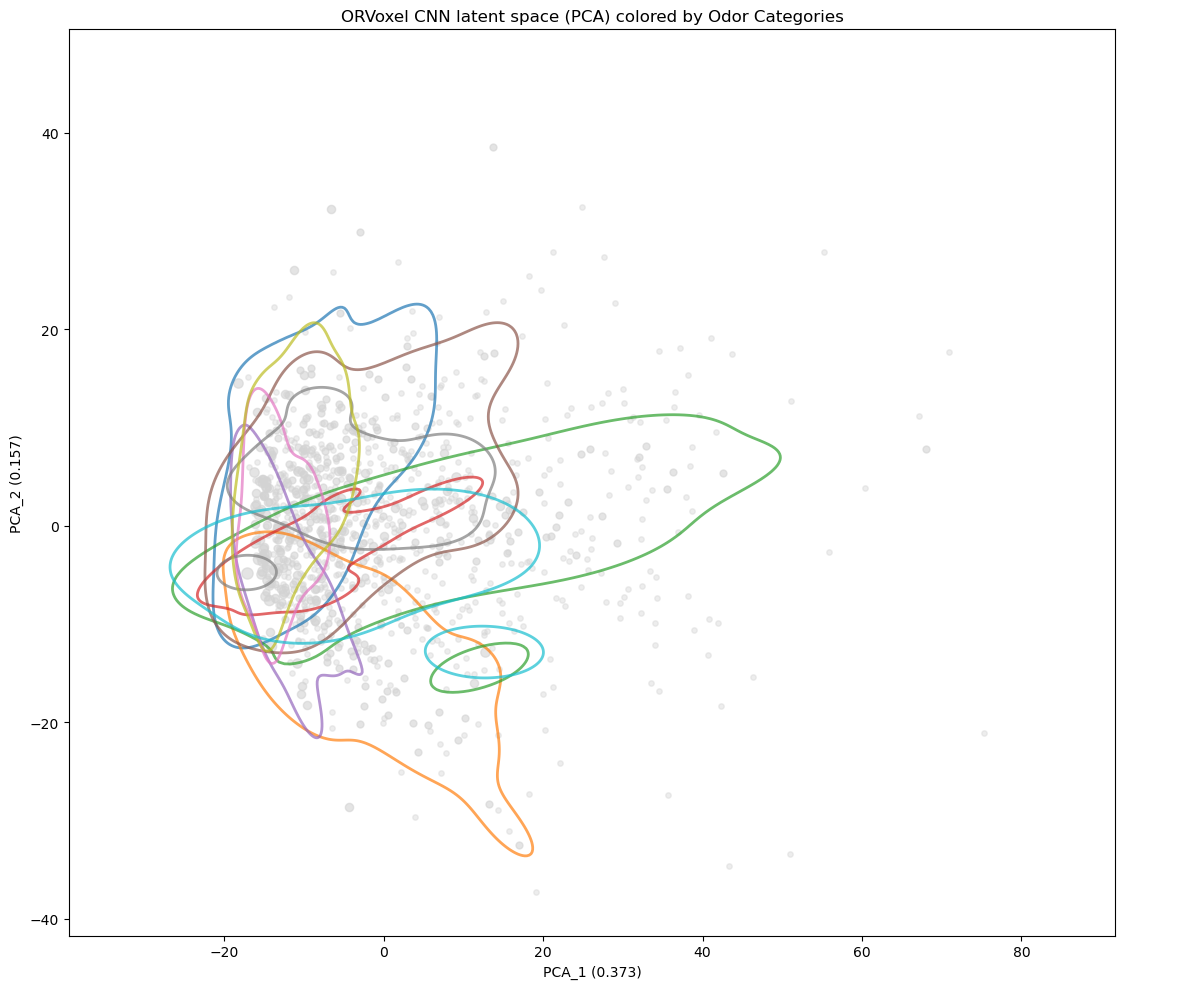

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- ODOR category mapping ---
ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(all_features)
pca_variance = pca.explained_variance_ratio_

# Build PCA dataframe
pca_df = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

# Create a multi-hot matrix: OR x odor categories
# all_labels is [num_OR x num_odor_classes], 1 if OR activated by odor
odor_activation = all_labels.astype(bool)

# For convenience, store which ORs are activated by which odor
pca_df_odors = []
for i in range(odor_activation.shape[0]):
    active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(odor_activation[i]) if v]
    pca_df_odors.append(active_odors)
pca_df['active_odors'] = pca_df_odors

# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')

# --- Plot ---
plt.figure(figsize=(12,10))

# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in pca_df.iterrows():
    if row['active_odors']:
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    # color=color_map[row['active_odors'][0]],
                    color = '#D3D3D3',
                    s=15 + (10*len(row['active_odors'])), alpha=0.6)
    else:
        plt.scatter(row['PCA_1'], row['PCA_2'], color='lightgray', s=15, alpha=0.4)

# KDE contour per odor category
for odor in ODOR_CATEGORIES:
    subset = pca_df[[odor in active for active in pca_df['active_odors']]]
    if len(subset) < 2:
        continue  # skip odors with too few ORs
    sns.kdeplot(
        x=subset['PCA_1'], y=subset['PCA_2'],
        levels=2,
        thresh=0.1,
        color=color_map[odor],
        linewidths=2,
        alpha=0.7,
        label=odor,
        warn_singular=False
    )

plt.xlabel(f'PCA_1 ({pca_variance[0]:.3f})')
plt.ylabel(f'PCA_2 ({pca_variance[1]:.3f})')
plt.title("ORVoxel CNN latent space (PCA) colored by Odor Categories")
plt.legend(edgecolor='None', markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/home/hl307@dhe.duke.edu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hl307@dhe.duke.edu/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hl307@dhe.duke.edu/anaconda3/envs/umap_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


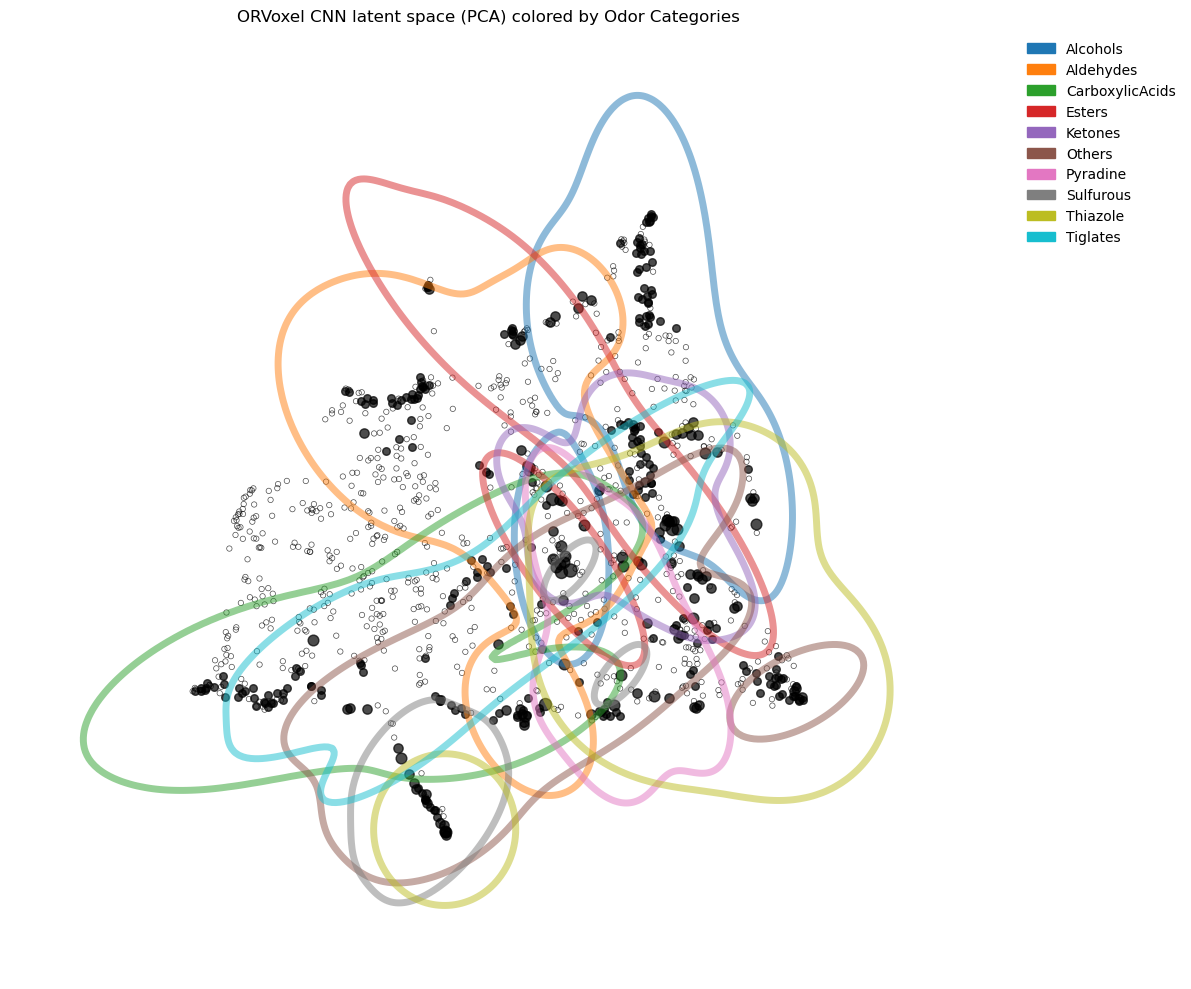

In [ ]:
import matplotlib.patches as mpatches
import umap 
import re 

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(all_features)

# Build PCA dataframe
umap_df = pd.DataFrame(X_umap, columns=['UMAP_1', 'UMAP_2'])

# Create a multi-hot matrix: OR x odor categories
# all_labels is [num_OR x num_odor_classes], 1 if OR activated by odor
odor_activation = all_labels.astype(bool)

# For convenience, store which ORs are activated by which odor
umap_df_odors = []
for i in range(odor_activation.shape[0]):
    active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(odor_activation[i]) if v]
    umap_df_odors.append(active_odors)
umap_df['active_odors'] = umap_df_odors


fam_label = []
for _label in voxel_names: 
    fam_label.append(re.match(r'Or(\d+)', _label, re.IGNORECASE).group(1))
fam_label = np.array(fam_label)

# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')

# --- Plot ---
plt.figure(figsize=(12,10))

# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in umap_df.iterrows():
    if row['active_odors']:
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    color = 'black',
                    s=15 + (15*len(row['active_odors'])), alpha=0.7)
    else:
        # plt.scatter(row['UMAP_1'], row['UMAP_2'], color='lightgray', s=15, alpha=0.4)
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    edgecolor = 'black', facecolor='none',lw=0.5,
                    s=15, alpha=0.7)

legend_patches = []
# KDE contour per odor category
for odor in ODOR_CATEGORIES:
    subset = umap_df[[odor in active for active in umap_df['active_odors']]]
    if len(subset) < 2:
        continue  # skip odors with too few ORs
    sns.kdeplot(
        x=subset['UMAP_1'], y=subset['UMAP_2'],
        levels=2,
        thresh=0.1,
        color=color_map[odor],
        linewidths=5,
        alpha=0.5,
        label=odor,
        warn_singular=False, 
        legend=True
    )
    legend_patches.append(mpatches.Patch(color=color_map[odor], label=odor))


plt.xlabel(f'UMAP_1')
plt.ylabel(f'UMAP_2')
plt.title("ORVoxel CNN latent space (UMAP) colored by Odor Categories")
plt.legend(handles=legend_patches,
           edgecolor='None', markerscale=2,
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# TODO color umap based on family members

In [7]:
"""
Reload the voxel in sparse form and no radius for visualization 
"""

Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

# Extracting the voxels used in model 
Cbc_cav_coords = {_key: _values for _key, _values in Cbc_cav_coords.items() if _key in voxel_names}
Cbc_res_coords = {_key: _values for _key, _values in Cbc_res_coords.items() if _key in voxel_names}

center_reference = np.load('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_center_reference.npy')
voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                        residue_coords = Cbc_res_coords,
                                        resolution = 1, 
                                        cube_dim = 32, reference_center = center_reference, 
                                        encode_method='res', 
                                        sparse_mode=True, 
                                        vdw_radius = False)

# Trim down voxels to save memory 
del Cbc_cav_coords, Cbc_res_coords


Encoding voxels via res...
Generating voxels. . .


100%|██████████| 1115/1115 [00:04<00:00, 271.11it/s]


In [8]:
# all_labels is [num_OR x num_odor_classes], 1 if OR activated by odor
odor_activation = all_labels.astype(bool)

# For convenience, store which ORs are activated by which odor
all_labels_odors = []
for i in range(odor_activation.shape[0]):
    active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(odor_activation[i]) if v]
    all_labels_odors.append(active_odors)


In [9]:
ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

In [11]:
import plotly.graph_objects as go 


# all_labels is [num_OR x num_odor_classes], 1 if OR activated by odor
odor_activation = all_labels.astype(bool)
# For convenience, store which ORs are activated by which odor
all_labels_odors = []
for i in range(odor_activation.shape[0]):
    active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(odor_activation[i]) if v]
    all_labels_odors.append(active_odors)


_ODOR = 'Sulfurous'

plot_voxels = [voxels[i] for i, _odors in enumerate(all_labels_odors) if _ODOR in _odors]
plot_voxels_cons = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.1)
positions = np.array(list(plot_voxels_cons))

X, Y, Z = positions[:,0], positions[:,1], positions[:,2]

res = np.array(list(plot_voxels_cons.values()))[:,0]
cons_ratio = np.array(list(plot_voxels_cons.values()))[:,1]

color = cf.distinct_colors(list(vf.AA_RES_OHE), category='tab20')
IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=X, y=Y, z=Z,
    mode='markers',
    name="_ODOR",
    marker=dict(
        size=5,  # adjust marker size
        color=[color.get(IDX_TO_AA_RES.get(_res)) for _res in res],  # importance values
        opacity=0.8
    ), 
    # text=[f"Residue {n} {IDX_TO_AA_RES.get(r)}" for n, r in zip(res_num.astype(int), res)],  # hover text
    text=[f"{IDX_TO_AA_RES.get(_r)}, {np.round(_ratio, 2)}%" for _r, _ratio in zip(res, cons_ratio)],  # hover text
    hoverinfo="text"
))
    
    
# Add importance volumes
plot_voxel = odor_importances[_ODOR]
X, Y, Z = np.indices(plot_voxel.shape)

# fig.add_trace(go.Volume(
#     x=X.flatten(),
#     y=Y.flatten(),
#     z=Z.flatten(),
#     name='feature', 
#     value=[i if ((i <= -1e-2) | 
#                  (i >=  1e-2)) else 0 for i in plot_voxel.flatten()],
#     isomin=-np.max(np.abs(plot_voxel)),
#     isomax= np.max(np.abs(plot_voxel)),
#     opacity=0.5,  # global scaling factor
#     surface_count=10,  # number of contour surfaces
#     colorscale="RdBu_r", # red/blue diverging
#     showscale=False,
#     showlegend=True, 
#     hoverinfo='skip', 
#     caps=dict(x_show=False, y_show=False, z_show=False)  # hide box caps
# ))

plot_voxel = odor_importances[_ODOR]
occupied_voxels = np.array(np.where((plot_voxel > 1e-2) |
                                    (plot_voxel < -1e-2))).T
x, y, z = occupied_voxels[:, 0], occupied_voxels[:, 1], occupied_voxels[:, 2]
values = plot_voxel[x, y, z]

# Plot scatter with color scale
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    name="Importance",
    marker=dict(
        size=3,  # adjust marker size
        color=values,  # importance values
        colorscale="RdBu_r",  # red-blue colormap
        cmin=-np.max(np.abs(values)),  # symmetric color range
        cmax=np.max(np.abs(values)),
        opacity=1,
        colorbar=dict(title="Importance", 
                      len=0.7,  # Length of the colorbar (fraction of plot height)
                      lenmode='fraction', # Can be 'fraction' or 'pixels'
                      thickness=20, # Thickness of the colorbar in pixels
                      thicknessmode='pixels'
                      )
    )
))

# fig.update_layout(
#     xaxis_fixedrange=True,
#     yaxis_fixedrange=True
# )


fig = pf._plotly_blank_style(fig)
fig.show()

# fig.write_html(os.path.join(base_dir, f'importance_{_ODOR}_consvox.html'))



In [ ]:
# Extract BW positions or at least residue number from alignment. 
# TODO identify BW number from cons 

In [42]:
from Bio import SeqIO

fasta_path = '/mnt/data2/Justice/OR_learning/files/OR_seq/mouseOR_alignment.fasta'
Olfr_DL = np.load('/mnt/data2/Justice/OR_learning/files/Olfr_DL.npy', allow_pickle=True).item()

sequences = []
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_str = str(record.seq)
    sequences.append((record.id, seq_str))
    
alignment_df = pd.DataFrame(
    [list(seq) for _, seq in sequences],
    columns=range(1, len(sequences[0][1]) + 1),
    index=[Olfr_DL.get(seq_id, seq_id).capitalize() for seq_id, _ in sequences]
)

In [37]:
"""
Make Voxel_info df 
"""

odor_activation = all_labels.astype(bool)
# For convenience, store which ORs are activated by which odor
all_labels_odors = []
for i in range(odor_activation.shape[0]):
    active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(odor_activation[i]) if v]
    all_labels_odors.append(active_odors)
    
import re
fam = []
for or_name in voxel_names:
    fam.append(int(re.match(r'Or(\d+)', or_name, re.IGNORECASE).group(1)))

# Make voxel_info df 
voxels_info = pd.DataFrame([_name.capitalize() for _name in voxel_names], columns = ['voxel_name'])
voxels_info['OR'] = voxels_info.voxel_name.str.split('_').str[0]
voxels_info['family'] = fam
voxels_info['label'] = list(all_labels.astype(int))
voxels_info['odor_response'] = list(all_labels_odors)

    
    

In [49]:
odor_idx = [ i for i, _odors in enumerate(voxels_info['odor_response']) if 'Sulfurous' in _odors]

voxels_info.loc[odor_idx]

,voxel_name,OR,family,label,odor_response
65,Or5p1_0,Or5p1,5,"[1, 0, 0, 1, 1, 0, 1, 1, 0, 0]","[Alcohols, Esters, Ketones, Pyradine, Sulfurous]"
217,Or2t44_0,Or2t44,2,"[0, 0, 0, 0, 0, 1, 0, 1, 0, 0]","[Others, Sulfurous]"
234,Or4k52_0,Or4k52,4,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0]","[Sulfurous, Thiazole]"
266,Or2m13_0,Or2m13,2,"[0, 0, 0, 0, 0, 1, 0, 1, 1, 0]","[Others, Sulfurous, Thiazole]"
312,Or2t43_0,Or2t43,2,"[0, 0, 0, 0, 0, 1, 0, 1, 0, 0]","[Others, Sulfurous]"
323,Or4k49_0,Or4k49,4,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]",[Sulfurous]
340,Or4k42_0,Or4k42,4,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]",[Sulfurous]
436,Or4s2b_0,Or4s2b,4,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]",[Sulfurous]
459,Or5k3_0,Or5k3,5,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]",[Sulfurous]
461,Or2t46_0,Or2t46,2,"[0, 0, 1, 0, 0, 1, 0, 1, 0, 0]","[CarboxylicAcids, Others, Sulfurous]"


In [ ]:
"""
Construct overall consensus for better alignment to find BW numbers 
"""

percent_dashes = (alignment_df == '-').sum(axis=0) / alignment_df.shape[0] * 100
drop_threshold = 60

cols_to_drop = percent_dashes[percent_dashes >= drop_threshold].index.tolist()
consensus_df = alignment_df.drop(columns=cols_to_drop)
consensus_df.columns = list(range(len(consensus_df.columns))) # Re-name columns 

In [66]:
IDX_TO_AA_RES

{1: 'ALA',
 2: 'GLY',
 3: 'ILE',
 4: 'LEU',
 5: 'MET',
 6: 'VAL',
 7: 'PHE',
 8: 'TRP',
 9: 'TYR',
 10: 'ASN',
 11: 'CYS',
 12: 'GLN',
 13: 'PRO',
 14: 'SER',
 15: 'THR',
 16: 'ASP',
 17: 'GLU',
 18: 'ARG',
 19: 'HIS',
 20: 'LYS',
 21: 'UNK'}

In [69]:
np.unique([i for i in plot_voxels[0].values()])

array([  1.,   2.,   3.,   6.,   7.,   9.,  10.,  11.,  15.,  73., 104.,
       105., 108., 109., 112., 155., 159., 203., 206., 207., 251., 255.,
       259.], dtype=float32)

In [ ]:
#TODO Assign and extract BW numbers 
consensus_df.loc[list(voxels_info.loc[odor_idx].OR.values) + ['Or51e2']]

,0,1,2,3,4,5,6,7,8,9,...,307,308,309,310,311,312,313,314,315,316
Or5p1,M,E,P,G,N,H,T,A,V,T,...,T,L,R,I,Y,S,-,-,-,-
Or2t44,-,-,M,D,R,G,N,T,T,A,...,V,T,R,C,A,A,L,T,S,K
Or4k52,M,D,G,G,N,H,S,L,V,S,...,I,N,N,Y,M,D,S,Q,G,K
Or2m13,M,Q,W,N,N,W,T,R,N,S,...,L,R,M,D,K,A,A,G,-,-
Or2t43,-,-,M,S,N,Y,T,G,Q,S,...,L,G,I,R,L,H,F,P,E,T
Or4k49,M,N,G,V,N,E,S,T,V,S,...,K,S,Y,V,M,N,H,K,V,N
Or4k42,M,D,E,G,N,H,T,M,V,S,...,I,S,N,Y,L,S,H,K,G,N
Or4s2b,Y,S,M,E,E,V,N,N,V,T,...,W,A,R,K,F,S,W,E,T,T
Or5k3,M,A,E,N,N,Y,S,V,T,N,...,M,K,R,R,-,-,-,-,-,-
Or2t46,T,W,M,N,N,Y,T,T,Q,S,...,L,G,V,K,P,F,F,Q,E,S


## OR Family classification 

In [298]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA
# import umap


base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_ORclassify/param_sweep2/20250828_211633_lr0.001_bs8_hd32_ks3_nl2_do0.2_ptMAX_agmntFalse'
params_path = os.path.join(base_dir, "params.json")
model_path = os.path.join(base_dir, "best_model.pt")

# Predefine the family classes once
FAMILIES = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,51,52,55,56]
FAMILY_TO_IDX = {fam: i for i, fam in enumerate(FAMILIES)}
IDX_TO_FAMILY = {i: fam for i, fam in enumerate(FAMILIES)}
NUM_CLASSES = len(FAMILIES)

with open(params_path, "r") as f:
    params = json.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset definition 
class ORVoxelDataset(Dataset):
    def __init__(self, voxel_tensor, or_index_map, family_map):
        """
        voxel_tensor: [N, D, H, W, C]
        or_index_map: dict mapping OR name -> index in voxel_tensor
        family_map: dict mapping OR name -> family label (int)
        """
        self.voxel_tensor = voxel_tensor
        self.or_names = list(or_index_map.keys())
        self.or_indices = list(or_index_map.values())
        self.labels = [family_map[name] for name in self.or_names]

    def __len__(self):
        return len(self.or_indices)

    def __getitem__(self, idx):
        voxel = self.voxel_tensor[self.or_indices[idx]]
        target = self.labels[idx]
        return torch.tensor(voxel, dtype=torch.float32), torch.tensor(target, dtype=torch.long)

# Model Definition 
import torch.nn as nn
class ORFamilyCNN(nn.Module):
    def __init__(self, voxel_shape=(41, 42, 65), num_classes=18,
                 kernel_size=3, hidden_dim=256,
                 num_conv_layers=2, conv_channels=(16, 32),
                 dropout=0.0, pool_type='AVG'):
        super().__init__()
        C, D, H, W = voxel_shape
        layers = []
        in_channels = C
        pool = nn.AvgPool3d if pool_type == 'AVG' else nn.MaxPool3d

        for i in range(num_conv_layers):
            out_channels = conv_channels[i]
            layers.append(nn.Conv3d(in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2))
            layers.append(nn.ReLU())
            layers.append(pool(2))
            in_channels = out_channels

        self.cnn = nn.Sequential(*layers)

        # Compute flattened CNN output size
        dummy = torch.zeros(1, C, D, H, W)
        with torch.no_grad():
            out = self.cnn(dummy)
        self.cnn_out_dim = out.reshape(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(self.cnn_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)  # output logits for each class
        )

    def forward(self, voxel, return_features=False):
        voxel = voxel.permute(0, 4, 1, 2, 3)  # [B, D,H,W,C] -> [B,C,D,H,W]
        cnn_out = self.cnn(voxel)
        cnn_out = cnn_out.reshape(cnn_out.size(0), -1)
        features = self.relu(self.fc1(cnn_out))
        features = self.dropout(features)
        if return_features:
            return features
        return self.fc_out(features)

    


In [7]:

Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

# For troubleshooting, using only 100 voxels 
Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords)[::2]}
Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords)[::2]}

voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                        residue_coords = Cbc_res_coords,
                                        resolution = 1, 
                                        encode_method='ohe', 
                                        vdw_radius = True)


# # Trim down voxels to save memory 
voxel_label = list(Cbc_cav_coords.keys())
del Cbc_cav_coords, Cbc_res_coords

voxels = voxels[:500]
voxel_label = voxel_label[:500]


Encoding voxels via ohe...
Generating voxels. . .


100%|██████████| 2777/2777 [04:26<00:00, 10.41it/s]


In [299]:
# Load Model Weights 
voxel_tensor = torch.stack(voxels) 
voxel_shape = voxel_tensor.shape
C, D, H, W = voxel_shape[-1], voxel_shape[1], voxel_shape[2], voxel_shape[3]

model = ORFamilyCNN(
    # voxel_shape=(C, D, H, W), # adjust if needed
    voxel_shape=(21, 44, 38, 46), # Defined from running [::2] on all Cbc_cav_coords()
    num_classes=NUM_CLASSES,
    kernel_size=params["kernel_size"],
    hidden_dim=params["hidden_dim"],
    num_conv_layers=params["num_conv_layers"],
    conv_channels=tuple([16 * 2**i for i in range(params['num_conv_layers'])]),
    dropout=params["dropout"],
    pool_type=params["pooling"]
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

ORFamilyCNN(
  (cnn): Sequential(
    (0): Conv3d(21, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): ReLU()
    (5): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=34848, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=18, bias=True)
  )
)

In [300]:
def model_wrapper(voxel_input):
    """
    Forward pass through CNN + FC for Captum.
    voxel_input: [B,D,H,W,C]
    returns: logits [B,num_classes]
    """
    x = voxel_input.permute(0, 4, 1, 2, 3)           # [B,D,H,W,C] -> [B,C,D,H,W]
    x = model.cnn(x)
    x = x.reshape(x.size(0), -1)
    x = model.fc(x)                                  # use entire Sequential
    return x

def extract_features(model, x):
    x = x.permute(0, 4, 1, 2, 3)  # [B,D,H,W,C] -> [B,C,D,H,W]
    cnn_out = model.cnn(x)
    cnn_out = cnn_out.reshape(cnn_out.size(0), -1)
    # Use first Linear layer output as features
    features = model.fc[1](model.fc[0](cnn_out))  # fc[0]: Linear, fc[1]: ReLU
    return features

from captum.attr import IntegratedGradients

ig = IntegratedGradients(model_wrapper)
def compute_attributions(voxel_batch, target_labels):
    """
    voxel_batch: [B,D,H,W,C] tensor
    target_labels: [B] tensor of class indices
    returns: importance map per voxel, same shape as input without channel dim
    """
    voxel_batch = voxel_batch.to(device)
    voxel_batch.requires_grad_()

    attributions = ig.attribute(voxel_batch, target=target_labels, 
                                n_steps=10, internal_batch_size=1)
    # sum across feature channels for a single importance score per voxel
    importance = attributions.detach().cpu().sum(dim=-1)
    return importance  # shape [B,D,H,W]


n_voxels = len(voxels)

# Prepare input data 
family_map = {}
for or_name in voxel_label:
    import re
    match = re.match(r'Or(\d+)', or_name, re.IGNORECASE)
    fam = int(match.group(1)) if match else 0
    family_map[or_name] = FAMILY_TO_IDX[fam]

dataset = ORVoxelDataset(voxels, {k: i for i, k in enumerate(voxel_label)}, family_map)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Extract Embedding
all_importances, all_features, all_labels = [], [], []
for voxel_batch, label_batch in dataloader:
    # Compute embedding
    feats = extract_features(model, voxel_batch.to(device))
    all_features.append(feats.cpu())
    
    # Compute Captum attribution map
    importance = compute_attributions(voxel_batch, label_batch.to(device))
    importance = importance.detach().cpu()
    all_importances.append(importance)
    
    # Store labels
    all_labels.append(label_batch)
    
    # Free up memory 
    del voxel_batch
    torch.cuda.empty_cache()

all_features = torch.cat(all_features).detach().numpy()
all_labels = torch.cat(all_labels).detach().numpy()
all_importances = torch.cat(all_importances).detach().numpy()

# np.save(os.path.join(base_dir, "embeddings.npy"), all_features)
# np.save(os.path.join(base_dir, "labels.npy"), all_labels)
# np.save(os.path.join(base_dir, "importances.npy"), all_importances)

np.save(os.path.join(base_dir, f"embeddings_n{n_voxels}.npy"), all_features)
np.save(os.path.join(base_dir, f"labels_n{n_voxels}.npy"), all_labels)
np.save(os.path.join(base_dir, f"importances_n{n_voxels}.npy"), all_importances)

print("Saved embeddings:", all_features.shape)
print("Saved labels:", all_labels.shape)
print("Saved voxel importances:", all_importances.shape)


/tmp/ipykernel_3236822/1069101988.py:45: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



Saved embeddings: (500, 32)
Saved labels: (500,)
Saved voxel importances: (500, 44, 38, 46)


In [3]:
n_voxels = 500

base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_ORclassify/param_sweep2/20250828_211633_lr0.001_bs8_hd32_ks3_nl2_do0.2_ptMAX_agmntFalse'

all_features = np.load(os.path.join(base_dir, f"embeddings_n{n_voxels}.npy"))
all_labels = np.load(os.path.join(base_dir, f"labels_n{n_voxels}.npy"))
all_importances = np.load(os.path.join(base_dir, f"importances_n{n_voxels}.npy"))


/tmp/ipykernel_3236822/3426773556.py:30: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

/tmp/ipykernel_3236822/3426773556.py:30: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

/tmp/ipykernel_3236822/3426773556.py:30: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

/tmp/ipykernel_3236822/3426773556.py:30: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

/tmp/ipykernel_3236822/3426773556.py:30: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

/tmp/ipykernel_3236822/3426773556.py:30: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

/tmp/ipykernel_3236822/3426773556.py:30: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

/tmp/ipykernel_3236822/3426773556.py:30: UserWarning:

No data for co

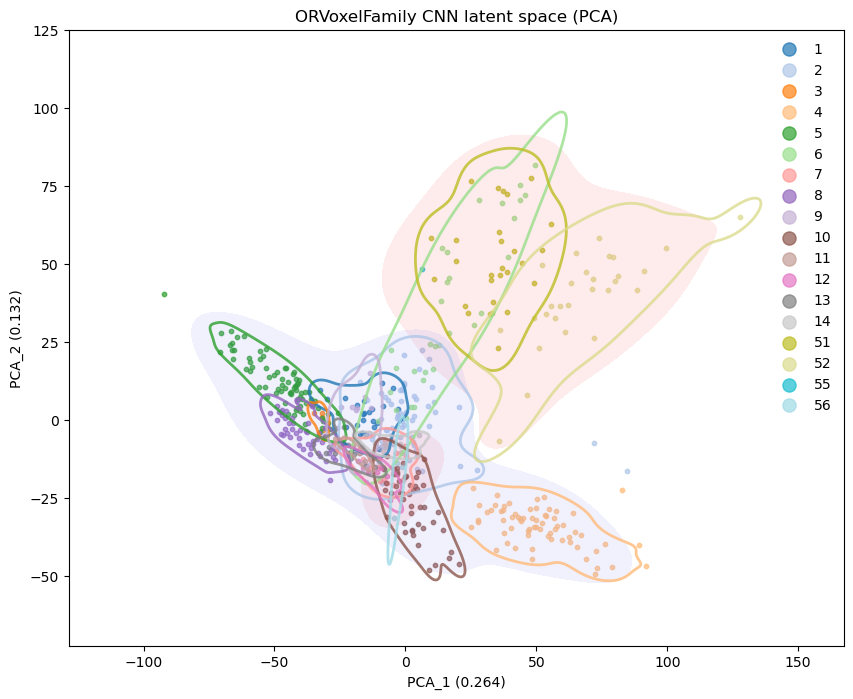

In [303]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 
import seaborn as sns 


# Predefine the family classes once
FAMILIES = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,51,52,55,56]
FAMILY_TO_IDX = {fam: i for i, fam in enumerate(FAMILIES)}
IDX_TO_FAMILY = {i: fam for i, fam in enumerate(FAMILIES)}
NUM_CLASSES = len(FAMILIES)

# Embedding plots 
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(all_features)
pca_variance = pca.explained_variance_ratio_


pca_df = pd.DataFrame(X_pca, columns = ['PCA_1', 'PCA_2'])
pca_df['family'] = [IDX_TO_FAMILY.get(_label) for _label in all_labels]
pca_df['class'] = [2 if IDX_TO_FAMILY.get(_label) < 20 else 1 for _label in all_labels ]


color = cf.distinct_colors(FAMILIES, category='tab20')

plt.figure(figsize=(10,8))

for _fam in np.sort(pca_df.family.unique()): 
    subset_df = pca_df[pca_df['family'] == _fam]
    plt.scatter(subset_df['PCA_1'], 
                subset_df['PCA_2'], 
                c=color.get(_fam), 
                label=_fam, 
                cmap="tab20", s=10, alpha=0.7)
    
    # KDE contour
    sns.kdeplot(
        x=subset_df['PCA_1'], y=subset_df['PCA_2'],
        levels=2,  # number of contour levels
        thresh=0.1,  # density threshold for showing
        color=color.get(_fam),
        linewidths=2,
        alpha=0.8, 
        warn_singular=False
    )

for _class in np.sort(pca_df['class'].unique()): 
    subset_df = pca_df[pca_df['class'] == _class]
    sns.kdeplot(
            x=subset_df['PCA_1'], y=subset_df['PCA_2'],
            fill=True, 
            levels=2,  # number of contour levels
            thresh=0.1,  # density threshold for showing
            color = 'Red' if _class == 1 else 'Blue',
            linewidths=2,
            alpha=0.1, 
            label=_class, 
            warn_singular=False, 
            legend=True
        )

# plt.axis('off')
plt.xlabel(f'PCA_1 ({pca_variance[0]:.3f})')
plt.ylabel(f'PCA_2 ({pca_variance[1]:.3f})')
plt.legend(edgecolor='None', markerscale=3)
# plt.colorbar()
plt.title("ORVoxelFamily CNN latent space (PCA)")
plt.savefig(f'/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_ORclassify/features/PCA_features_n{n_voxels}.png', dpi=300)
plt.show()

# TODO Include umap as well. 
# UMAP
# reducer = umap.UMAP(n_components=2, random_state=42)
# X_umap = reducer.fit_transform(all_features)

# plt.figure(figsize=(6,5))
# plt.scatter(X_umap[:,0], X_umap[:,1], c=all_labels, cmap="tab20", s=12, alpha=0.7)
# plt.colorbar()
# plt.title("CNN latent space (UMAP)")
# plt.show()

/home/hl307@dhe.duke.edu/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hl307@dhe.duke.edu/anaconda3/envs/umap_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_3421916/2887854581.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(subset_df['UMAP_1'],
/tmp/ipykernel_3421916/2887854581.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(subset_df['UMAP_1'],
/tmp/ipykernel_3421916/2887854581.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(subset_df['UMAP_1'],
/tmp/ipykernel_3421916/2887854581.py:26: UserWarning: No data for colormapping pro

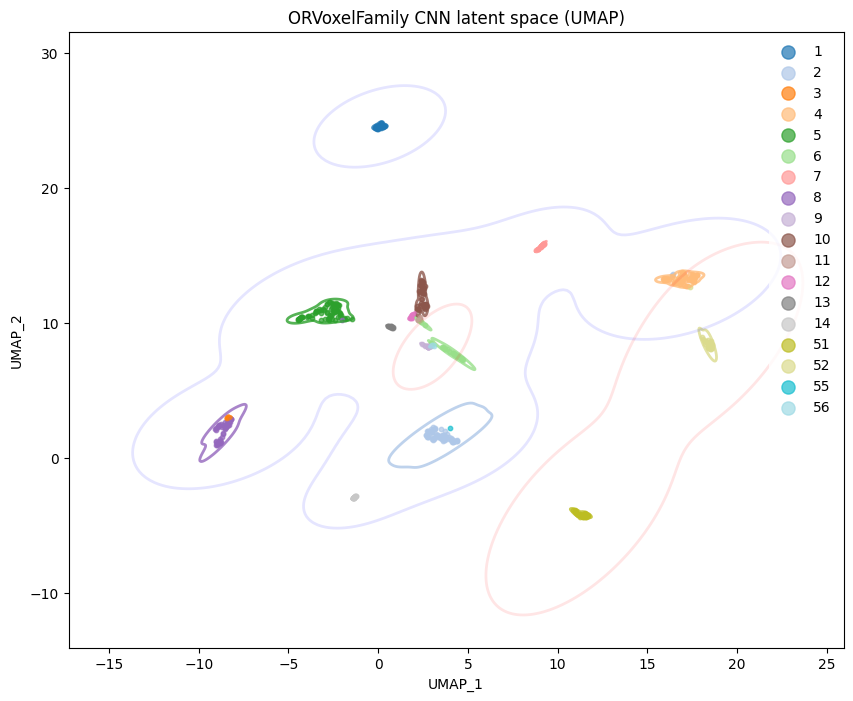

In [43]:
import matplotlib.patches as mpatches
import umap 

# Predefine the family classes once
FAMILIES = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,51,52,55,56]
FAMILY_TO_IDX = {fam: i for i, fam in enumerate(FAMILIES)}
IDX_TO_FAMILY = {i: fam for i, fam in enumerate(FAMILIES)}
NUM_CLASSES = len(FAMILIES)

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(all_features)

# Build PCA dataframe
umap_df = pd.DataFrame(X_umap, columns=['UMAP_1', 'UMAP_2'])

umap_df['family'] = [IDX_TO_FAMILY.get(_label) for _label in all_labels]
umap_df['class'] = [2 if IDX_TO_FAMILY.get(_label) < 20 else 1 for _label in all_labels ]


color = cf.distinct_colors(FAMILIES, category='tab20')

plt.figure(figsize=(10,8))

for _fam in np.sort(umap_df.family.unique()): 
    subset_df = umap_df[umap_df['family'] == _fam]
    plt.scatter(subset_df['UMAP_1'], 
                subset_df['UMAP_2'], 
                c=color.get(_fam), 
                label=_fam, 
                cmap="tab20", s=10, alpha=0.7)
    
    # KDE contour
    sns.kdeplot(
        x=subset_df['UMAP_1'], y=subset_df['UMAP_2'],
        levels=2,  # number of contour levels
        thresh=0.1,  # density threshold for showing
        color=color.get(_fam),
        linewidths=2,
        alpha=0.8, 
        warn_singular=False
    )

for _class in np.sort(umap_df['class'].unique()): 
    subset_df = umap_df[umap_df['class'] == _class]
    sns.kdeplot(
            x=subset_df['UMAP_1'], y=subset_df['UMAP_2'],
            # fill=True, 
            levels=2,  # number of contour levels
            thresh=0.1,  # density threshold for showing
            color = 'Red' if _class == 1 else 'Blue',
            linewidths=2,
            alpha=0.1, 
            label=_class, 
            warn_singular=False, 
            legend=True
        )

# plt.axis('off')
plt.xlabel(f'UMAP_1')
plt.ylabel(f'UMAP_2')
plt.legend(edgecolor='None', markerscale=3)
# plt.colorbar()
plt.title("ORVoxelFamily CNN latent space (UMAP)")
# plt.savefig(f'/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_ORclassify/features/UMAP_features_n{n_voxels}.png', dpi=300)
plt.show()


In [5]:
"""
Extracts important features per family
"""

# Predefine the family classes once
FAMILIES = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,51,52,55,56]
FAMILY_TO_IDX = {fam: i for i, fam in enumerate(FAMILIES)}
IDX_TO_FAMILY = {i: fam for i, fam in enumerate(FAMILIES)}
NUM_CLASSES = len(FAMILIES)
IDX_TO_AA_RES = {i: aa for i, aa in enumerate(vf.AA_RES_OHE)}

fam_importance = {}
for _fam in np.sort(np.unique(all_labels)): 
    fam_importance[IDX_TO_FAMILY.get(_fam)] = all_importances[np.where(all_labels == 0)].mean(axis=0)

In [35]:
"""
Visualize importance cavity 
"""

import plotly.graph_objects as go 



fig = go.Figure()


In [146]:
import importlib 

importlib.reload(pf)
importlib.reload(cf)
importlib.reload(vf)

<module 'voxel_functions' from '/mnt/data2/Justice/OR_learning/utils/voxel_functions.py'>

In [6]:
"""
Reload the voxel in sparse form and no radius for visualization 
"""

Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

# For troubleshooting, using only 100 voxels 
Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords)[::2]}
Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords)[::2]}

voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                        residue_coords = Cbc_res_coords,
                                        resolution = 1, 
                                        encode_method='res', 
                                        vdw_radius = False, 
                                        sparse_mode=True
                                        )


# # Trim down voxels to save memory 
voxel_label = list(Cbc_cav_coords.keys())
del Cbc_cav_coords, Cbc_res_coords

sparse_voxels = voxels[:500]
voxel_label = voxel_label[:500]


Encoding voxels via res...
Generating voxels. . .


100%|██████████| 2777/2777 [00:10<00:00, 256.05it/s]


In [7]:
"""
Quickly convert label into family label 
"""
import re

fam_label = []
for _label in voxel_label: 
    fam_label.append(re.match(r'Or(\d+)', _label, re.IGNORECASE).group(1))

fam_label = np.array(fam_label)

In [ ]:
import plotly.graph_objects as go 



plot_aa_voxel = [sparse_voxels[i] for i in np.where(fam_label == '1')[0]]
positions = np.array(list(plot_aa_voxel[2]))
X, Y, Z = positions[:,0], positions[:,1], positions[:,2]

res_num, res = np.array(list(plot_aa_voxel[0].values()))[:,0], np.array(list(plot_aa_voxel[0].values()))[:,1]

color = cf.distinct_colors(list(vf.AA_RES_OHE), category='tab20')

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=X, y=Y, z=Z,
    mode='markers',
    name="Fam1",
    marker=dict(
        size=5,  # adjust marker size
        color=[color.get(IDX_TO_AA_RES.get(_res)) for _res in res],  # importance values
        opacity=0.8
    ), 
    text=[f"Residue {n} {IDX_TO_AA_RES.get(r)}" for n, r in zip(res_num, res)],  # hover text
    hoverinfo="text"
))

# Add dummy data for legend insertion
# for _aa_color in list(color):
#     fig.add_trace(go.Scatter3d(
#         x=[None], y=[None], z=[None],  # invisible
#         mode='markers',
#         marker=dict(
#             size=6,
#             color=color[_aa_color],
#         ),
#         name=str(_aa_color)  # shows up in legend
#     ))
    
    
    
# Add importance volumes
plot_voxel = fam_importance[1]
X, Y, Z = np.indices(plot_voxel.shape)

fig.add_trace(go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    name='feature', 
    value=plot_voxel.flatten(),
    isomin=-np.max(np.abs(plot_voxel)),
    isomax= np.max(np.abs(plot_voxel)),
    opacity=0.7,  # global scaling factor
    surface_count=10,  # number of contour surfaces
    colorscale="RdBu_r", # red/blue diverging
    showscale=False,
    showlegend=True, 
    caps=dict(x_show=False, y_show=False, z_show=False)  # hide box caps
))

# plot_voxel = fam_importance[1]
# occupied_voxels = np.array(np.where((plot_voxel > 1.5e-2) |
#                                     (plot_voxel < -1.5e-2))).T
# x, y, z = occupied_voxels[:, 0], occupied_voxels[:, 1], occupied_voxels[:, 2]
# values = plot_voxel[x, y, z]

# # Plot scatter with color scale
# fig.add_trace(go.Scatter3d(
#     x=x, y=y, z=z,
#     mode='markers',
#     name="Importance",
#     marker=dict(
#         size=3,  # adjust marker size
#         color=values,  # importance values
#         colorscale="RdBu_r",  # red-blue colormap
#         cmin=-np.max(np.abs(values)),  # symmetric color range
#         cmax=np.max(np.abs(values)),
#         opacity=1,
#         colorbar=dict(title="Importance")
#     )
# ))

fig.update_layout(
    xaxis_fixedrange=True,
    yaxis_fixedrange=True
)


fig = pf._plotly_blank_style(fig)
fig.show()

fig.write_html(os.path.join(base_dir, 'importance_fam1_vox.html'))



In [360]:
plot_voxel = fam_importance[1]

X, Y, Z = np.indices(plot_voxel.shape)

fig = go.Figure()

fig.add_trace(go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=plot_voxel.flatten(),
    isomin=-np.max(np.abs(plot_voxel)),
    isomax= np.max(np.abs(plot_voxel)),
    opacity=0.7,  # global scaling factor
    surface_count=10,  # number of contour surfaces
    colorscale="RdBu_r", # red/blue diverging
    caps=dict(x_show=False, y_show=False, z_show=False)  # hide box caps
))

# for i, _ in enumerate(fig.data): 
#     fig.data[i]['colorscale'] = ((1.0, 'rgba(103,0,31, 1)'),
#                       (0.9, 'rgba(178,24,43, 1)'),
#                       (0.8, 'rgba(214,96,77, 1)'),
#                       (0.6, 'rgba(244,165,130, 1)'),
#                     #   (0.4, 'rgba(253,219,199, 1)'),
#                       (0.5, 'rgba(247,247,247, 0)'),
#                     #   (0.6, 'rgba(209,229,240, 1)'),
#                       (0.4, 'rgba(146,197,222, 1)'),
#                       (0.2, 'rgba(67,147,195, 1)'),
#                       (0.1, 'rgba(33,102,172, 1)'),
#                       (0.0, 'rgba(5,48,97, 1)'))
    
fig = pf._plotly_blank_style(fig)
fig.show()